# Cyclistic — Bike-share analysis
**Google Data Analytics Certificate | Capstone Project**  
**Author:** Johannes Kuhaupt  
**Date:** July 2026  

## Overview

Analysis of Cyclistic's historical trip data to identify trends in how annual members and casual riders use the service differently. The primary analytical focus is question 1 — findings from this analysis directly inform the marketing recommendations for questions 2 and 3. The three guiding questions are:

1. How do annual members and casual riders use Cyclistic bikes differently?
2. Why would casual riders buy Cyclistic annual memberships?
3. How can Cyclistic use digital media to influence casual riders to become members?

**Key steps:**

* Imports & Setup (Python)
* Load & Merge Data (Python)
* Data Cleaning (Python)
* EDA — Dataset Overview (Python)
* EDA — Missing Station Investigation (Python)
* EDA — Ride Patterns (Python)
* EDA — Temporal Analysis (Python)
* EDA — Statistical Visualizations (R/ggplot2)
* EDA — Geospatial Analysis (Python)
* Summary of EDA Findings (Python)
* Top Three Recommendations
* Conclusion

## Data Sources

This analysis uses full-year 2025 trip data downloaded directly from the [Divvy trip data S3 bucket](https://divvy-tripdata.s3.amazonaws.com/index.html) (12 monthly ZIP files, Jan-Dec 2025).

## 1. Imports & Setup (Python)

In [4]:
# ── Install required libraries (run once per session) ──
!pip install folium rpy2 -q

# ── Data manipulation ──
import pandas as pd
import numpy as np
import glob
import os

# ── Visualization ──
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

# ── Settings ──
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# ── Notebook run metadata ──
from datetime import datetime
import pytz

# ── R integration ──
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


## 2. Load & Merge Data (Python)
   → 12 months of CSV files merged

In [5]:
# Step 1 — Remount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Step 2 — Then reload the data
dtype_dict = {
    'ride_id': 'str',
    'rideable_type': 'category',
    'member_casual': 'category',
    'start_station_name': 'str',
    'end_station_name': 'str',
    'start_station_id': 'str',
    'end_station_id': 'str'
}

# Load and merge all 12 CSV files
data_path = '/content/drive/MyDrive/Colab Notebooks/Cyclistic Capstone Project/divvy-tripdata/'

df = pd.concat([
    pd.read_csv(f, dtype=dtype_dict)
    for f in sorted(glob.glob(data_path + '*.csv'))
], ignore_index=True)

print(f'Total rows:    {df.shape[0]:,}')
print(f'Total columns: {df.shape[1]}')
print(f'Files loaded:  {len(glob.glob(data_path + "*.csv"))}')
df.head()

Total rows:    5,552,994
Total columns: 13
Files loaded:  12


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,41.892592,-87.617289,member
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,41.939743,-87.658865,member
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,41.945529,-87.646439,member
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member


## 3. Data Cleaning (Python)
   → remove nulls, fix data types,
     engineer ride duration

In [7]:
# Overview of data quality
print(df.info())
print()
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())
print()
print(df['member_casual'].value_counts())
print()
print(df['rideable_type'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5552994 entries, 0 to 5552993
Data columns (total 13 columns):
 #   Column              Dtype   
---  ------              -----   
 0   ride_id             object  
 1   rideable_type       category
 2   started_at          object  
 3   ended_at            object  
 4   start_station_name  object  
 5   start_station_id    object  
 6   end_station_name    object  
 7   end_station_id      object  
 8   start_lat           float64 
 9   start_lng           float64 
 10  end_lat             float64 
 11  end_lng             float64 
 12  member_casual       category
dtypes: category(2), float64(4), object(7)
memory usage: 476.6+ MB
None

Missing values per column:
ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1184673
start_station_id      1184673
end_station_name      1243305
end_station_id        1243305
start_lat                   0
start_l

In [8]:
# Step 1 — Copy raw dataframe
df1 = df.copy()

# Step 2 — Convert timestamps to datetime
df1['started_at'] = pd.to_datetime(df1['started_at'])
df1['ended_at'] = pd.to_datetime(df1['ended_at'])

# Step 3 — Calculate ride duration before cleaning
df1['ride_duration_mins'] = (
    df1['ended_at'] - df1['started_at']
).dt.total_seconds() / 60

# Step 4 — Count issues before removing
missing_coords = df1[['end_lat', 'end_lng']].isnull().any(axis=1).sum()
invalid_negative = (df1['ride_duration_mins'] <= 0).sum()
invalid_toolong = (df1['ride_duration_mins'] > 1440).sum()

print('Issues identified before cleaning:')
print(f'  Missing end coordinates:   {missing_coords:,}')
print(f'  Negative/zero durations:   {invalid_negative:,}')
print(f'  Durations > 24 hours:      {invalid_toolong:,}')
print(f'  Rows before cleaning:      {df1.shape[0]:,}')

# Step 5 — Remove invalid rows
df1 = df1.dropna(subset=['end_lat', 'end_lng'])
df1 = df1[df1['ride_duration_mins'] > 0]
df1 = df1[df1['ride_duration_mins'] <= 1440]

print(f'\nRows after cleaning:         {df1.shape[0]:,}')
print(f'Rows removed:                {df.shape[0] - df1.shape[0]:,}')

# Step 6 — Feature engineering
df1['hour'] = df1['started_at'].dt.hour
df1['day_of_week'] = df1['started_at'].dt.day_name()
df1['month'] = df1['started_at'].dt.month
df1['month_name'] = df1['started_at'].dt.strftime('%B')

df1['day_type'] = df1['day_of_week'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')

df1['season'] = df1['month'].apply(lambda x:
    'Winter' if x in [12, 1, 2] else
    'Spring' if x in [3, 4, 5] else
    'Summer' if x in [6, 7, 8] else 'Fall')

def get_time_of_day(hour):
    if hour < 6:
        return 'Night'
    elif hour < 12:
        return 'Morning'
    elif hour < 17:
        return 'Afternoon'
    elif hour < 21:
        return 'Evening'
    else:
        return 'Night'

df1['time_of_day'] = df1['hour'].apply(get_time_of_day)

# Step 7 — Verify missing station names
missing_stations = df1[df1['start_station_name'].isnull()]
print(f'\nRows with missing start station name: {len(missing_stations):,}')
print(f'Missing coordinates in those rows:    '
      f'{missing_stations[["start_lat","start_lng","end_lat","end_lng"]].isnull().sum().sum():,}')
print(f'Rideable type breakdown:')
print(missing_stations['rideable_type'].value_counts())

Issues identified before cleaning:
  Missing end coordinates:   5,535
  Negative/zero durations:   29
  Durations > 24 hours:      5,585
  Rows before cleaning:      5,552,994

Rows after cleaning:         5,547,221
Rows removed:                5,773

Rows with missing start station name: 1,184,669
Missing coordinates in those rows:    0
Rideable type breakdown:
rideable_type
electric_bike    1184669
classic_bike           0
Name: count, dtype: int64


**Data Cleaning Summary:**

Issues identified before cleaning:
- 5,535 rows with missing end coordinates
- 29 rows with negative or zero ride durations  
- 5,585 rows with ride durations exceeding 24 hours
- Total rows removed: 5,773 (some rows had multiple issues)

Actions taken:
- Converted `started_at` and `ended_at` to datetime format
- Removed rows with missing end coordinates
- Removed rows with invalid ride durations (≤ 0 or > 1,440 minutes)

Feature engineering:
- `ride_duration_mins` — ride duration in decimal minutes
- `hour`, `day_of_week`, `month`, `month_name` — time features
- `day_type` — Weekday vs Weekend
- `season` — Winter, Spring, Summer, Fall
- `time_of_day` — Night, Morning, Afternoon, Evening

**Note on missing station names:**
All 1,184,669 rows with missing start station names belong exclusively
to electric bikes — these bikes can be locked anywhere using GPS
tracking, not just at designated docking stations. These rows have
valid coordinates and timestamps and are retained for temporal and
coordinate-based analysis. They are excluded only from station-level
analysis.

**Final dataset:** 5,547,221 rides (January — December 2025)

**Shape:** 21 columns (13 original + 8 engineered)

In [9]:
# Final checks
# Check 1 — Head
df1.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_mins,hour,day_of_week,month,month_name,day_type,season,time_of_day
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,41.892592,-87.617289,member,13.957950,17,Tuesday,1,January,Weekday,Winter,Evening
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,41.939743,-87.658865,member,5.072400,15,Saturday,1,January,Weekend,Winter,Afternoon
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,41.945529,-87.646439,member,11.591667,15,Thursday,1,January,Weekday,Winter,Afternoon
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,3.570550,8,Thursday,1,January,Weekday,Winter,Morning
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,2.573817,8,Thursday,1,January,Weekday,Winter,Morning


In [10]:
# Check 2 — Describe
pd.set_option('display.float_format', '{:.2f}'.format)
df1.describe()

,started_at,ended_at,start_lat,start_lng,end_lat,end_lng,ride_duration_mins,hour,month
count,5547221,5547221,5547221.00,5547221.00,5547221.00,5547221.00,5547221.00,5547221.00,5547221.00
mean,2025-07-20 19:12:01.949239552,2025-07-20 19:26:33.057593856,41.90,-87.65,41.90,-87.65,14.52,14.00,7.13
min,2024-12-31 18:54:41.803000,2025-01-01 00:00:01.447000,41.65,-87.89,41.49,-88.10,0.00,0.00,1.00
25%,2025-05-28 09:00:27.988999936,2025-05-28 09:09:56.004000,41.88,-87.66,41.88,-87.66,5.39,10.00,5.00
50%,2025-07-26 17:19:22.225999872,2025-07-26 17:38:09.775000064,41.90,-87.64,41.90,-87.64,9.42,15.00,7.00
75%,2025-09-21 06:17:08.448000,2025-09-21 06:35:02.335000064,41.93,-87.63,41.93,-87.63,16.53,18.00,9.00
max,2025-12-31 23:53:24.274000,2025-12-31 23:58:42.046000,42.07,-87.52,42.21,-87.42,1439.98,23.00,12.00
std,NaN,NaN,0.04,0.03,0.04,0.03,28.38,4.96,2.62


**Describe() Summary:**

- `ride_duration_mins` — mean 14.52 mins, median 9.42 mins —
  right-skewed distribution as expected (some very long rides
  pull the mean up), 75% of rides are under 16.53 minutes
- `hour` — median 15 (3pm), mean 14 — confirms afternoon
  as peak usage period
- `month` — median 7 (July), mean 7.13 — confirms summer
  dominance in ride activity
- `started_at` min shows one ride starting 2024-12-31 —
  a late December ride ending after midnight on Jan 1st,
  which is valid and retained
- Coordinates centered around 41.90, -87.65 —
  confirms Chicago area
- Max duration 1,439.98 mins — just under our 24 hour
  threshold, correctly retained

In [11]:
# Check 3 — Missing values
print(df1.isnull().sum())
print()
print(f'Final dataset shape: {df1.shape}')
print(f'Final dataset: {df1.shape[0]:,} rides (January — December 2025)')

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1184669
start_station_id      1184669
end_station_name      1237671
end_station_id        1237671
start_lat                   0
start_lng                   0
end_lat                     0
end_lng                     0
member_casual               0
ride_duration_mins          0
hour                        0
day_of_week                 0
month                       0
month_name                  0
day_type                    0
season                      0
time_of_day                 0
dtype: int64

Final dataset shape: (5547221, 21)
Final dataset: 5,547,221 rides (January — December 2025)


**Summary of Final Checks:**

The final checks confirm a clean dataset. The final dataset contains
5,547,221 rides from January — December 2025 across 21 columns
(13 original + 8 engineered features). Data cleaning is complete —
next step is the Exploratory Data Analysis (EDA).

## 4. EDA — Ride Patterns (Python)

### 4.1 Dataset Overview

In [12]:
# Member/casual split
print('Member/Casual split:')
print(df1['member_casual'].value_counts())
print()
print(df1['member_casual'].value_counts(normalize=True).round(3))
print()

# Rideable type distribution
print('Rideable type distribution:')
print(df1['rideable_type'].value_counts())
print()
print(df1['rideable_type'].value_counts(normalize=True).round(3))

Member/Casual split:
member_casual
member    3552530
casual    1994691
Name: count, dtype: int64

member_casual
member   0.64
casual   0.36
Name: proportion, dtype: float64

Rideable type distribution:
rideable_type
electric_bike    3604936
classic_bike     1942285
Name: count, dtype: int64

rideable_type
electric_bike   0.65
classic_bike    0.35
Name: proportion, dtype: float64


**Dataset Overview:**

**Member/Casual split:**
- Members: 3,552,530 rides (64%)
- Casual riders: 1,994,691 rides (36%)
- The dataset is moderately imbalanced — members take significantly more rides than casual riders

**Rideable type distribution:**
- Electric bikes: 3,604,936 rides (65%)
- Classic bikes: 1,942,285 rides (35%)
- Electric bikes are the dominant bike type in 2025

**Note:** no docked bikes appear in the 2025 dataset — obviously Cyclistic has phased them out entirely.

### 4.2 Missing Station Name Investigation

In [13]:
# Start stations
missing_start = df1[df1['start_station_name'].isnull()]
print(f'Missing start station names: {len(missing_start):,} ({len(missing_start)/len(df1)*100:.1f}%)')
print(missing_start['rideable_type'].value_counts())
print()

# End stations
missing_end = df1[df1['end_station_name'].isnull()]
print(f'Missing end station names: {len(missing_end):,} ({len(missing_end)/len(df1)*100:.1f}%)')
print(missing_end['rideable_type'].value_counts())
print()

# 5 classic bikes with missing end stations
classic_missing = df1[
    (df1['end_station_name'].isnull()) &
    (df1['rideable_type'] == 'classic_bike')
]
print(f'Classic bikes with missing end station: {len(classic_missing)}')
print(classic_missing[['ride_id', 'started_at', 'ride_duration_mins',
                        'start_station_name', 'end_lat', 'end_lng']])

Missing start station names: 1,184,669 (21.4%)
rideable_type
electric_bike    1184669
classic_bike           0
Name: count, dtype: int64

Missing end station names: 1,237,671 (22.3%)
rideable_type
electric_bike    1237666
classic_bike           5
Name: count, dtype: int64

Classic bikes with missing end station: 5
                  ride_id              started_at  ride_duration_mins  \
458059   539D382552034794 2025-03-11 09:05:51.968              267.86   
1738846  2996ADF0E596D150 2025-06-04 17:20:10.850              216.46   
2080131  B6D01AB5788D1B70 2025-06-25 18:08:04.219              137.54   
2769593  D135FEDAC5ED8D6D 2025-07-01 14:33:33.463               84.35   
2875415  A722B60A6B4388D4 2025-07-30 02:30:55.413              866.25   

                start_station_name  end_lat  end_lng  
458059   St Louis Ave & Foster Ave    41.98   -87.72  
1738846         Wells St & 19th St    41.85   -87.63  
2080131      Michigan Ave & Oak St    41.91   -87.65  
2769593        Buckingham

**Missing Station Name Investigation:**

**Key findings:**

- **Missing start station names:** 1,184,669 (21.4%) — exclusively
electric bikes. Electric bikes can be unlocked from any location
using GPS tracking, not just designated docking stations, which
explains the absence of station names.

- **Missing end station names:** 1,237,671 (22.3%) — 1,237,666
electric bikes and 5 classic bikes. The slightly higher number
compared to start stations suggests some riders ended their trip
outside a designated station area.

- **5 classic bikes with missing end station names** show unusually
long ride durations (84–866 minutes), suggesting improper docking
or data entry errors. These 5 rows represent 0.0001% of the dataset
and are retained as their impact is negligible.

**Conclusion:** All rows with missing station names have valid
coordinates and timestamps and are retained for temporal and
coordinate-based analysis. They are excluded only from
station-level analysis.

### 4.3 Ride Patterns
    → Total rides by member type (bar chart)
    → Average ride duration by member type (bar chart)
    → Ride duration distribution (boxplot)
    → Rideable type preference by member type (grouped bar chart)

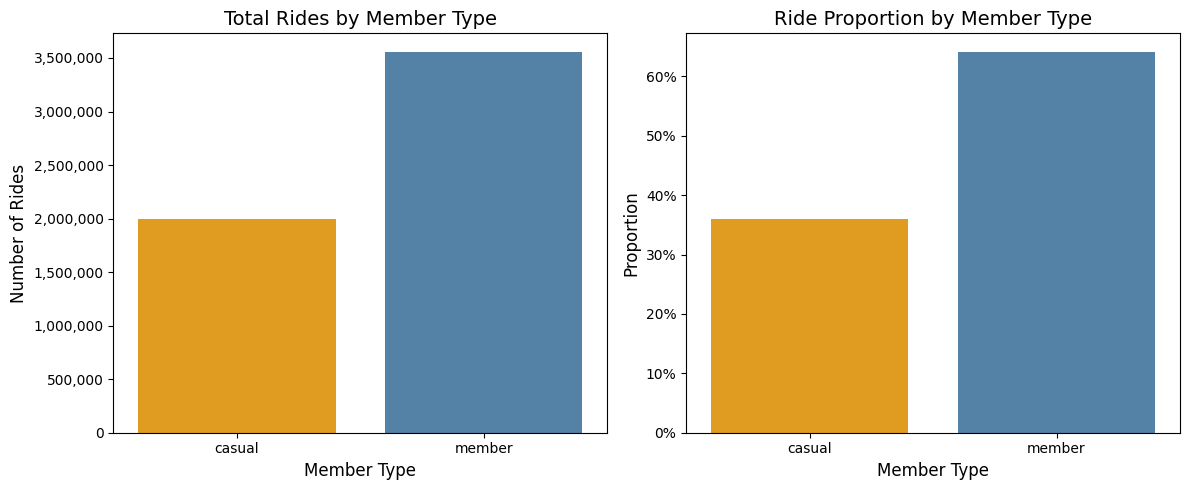

In [14]:
# Color palette — consistent throughout
palette = {'member': 'steelblue', 'casual': 'orange'}

# 4.3.1 Total rides by member type
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count
ride_counts = df1['member_casual'].value_counts().reset_index()
ride_counts.columns = ['member_casual', 'count']

sns.barplot(data=ride_counts, x='member_casual', y='count',
            palette=palette, ax=axes[0])
axes[0].set_title('Total Rides by Member Type', fontsize=14)
axes[0].set_xlabel('Member Type', fontsize=12)
axes[0].set_ylabel('Number of Rides', fontsize=12)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Proportion
ride_props = df1['member_casual'].value_counts(normalize=True).reset_index()
ride_props.columns = ['member_casual', 'proportion']

sns.barplot(data=ride_props, x='member_casual', y='proportion',
            palette=palette, ax=axes[1])
axes[1].set_title('Ride Proportion by Member Type', fontsize=14)
axes[1].set_xlabel('Member Type', fontsize=12)
axes[1].set_ylabel('Proportion', fontsize=12)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:.0%}'))

plt.tight_layout()
plt.show()

**Key Findings — Total Rides:**

- Members account for 64% of all rides (3,552,530) compared to 36%
for casual riders (1,994,691).
- While **members dominate ride volume, casual riders still represent a significant segment** — nearly 2 million rides in 2025 — making them a valuable conversion target for annual memberships.

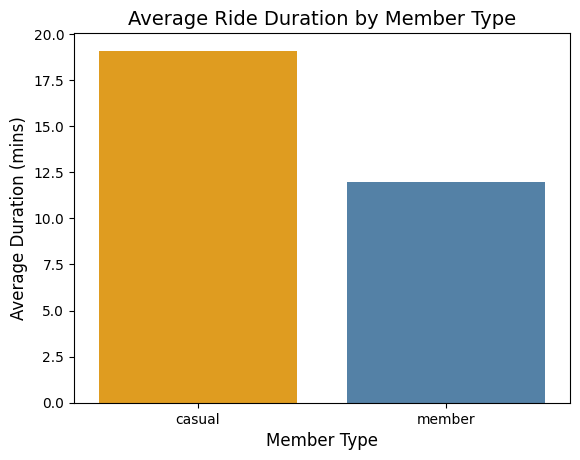

In [15]:
# 4.3.2 Average ride duration by member type
duration_avg = df1.groupby('member_casual')['ride_duration_mins'].mean().reset_index()

sns.barplot(data=duration_avg, x='member_casual', y='ride_duration_mins',
            palette=palette)
plt.title('Average Ride Duration by Member Type', fontsize=14)
plt.xlabel('Member Type', fontsize=12)
plt.ylabel('Average Duration (mins)', fontsize=12)
plt.show()

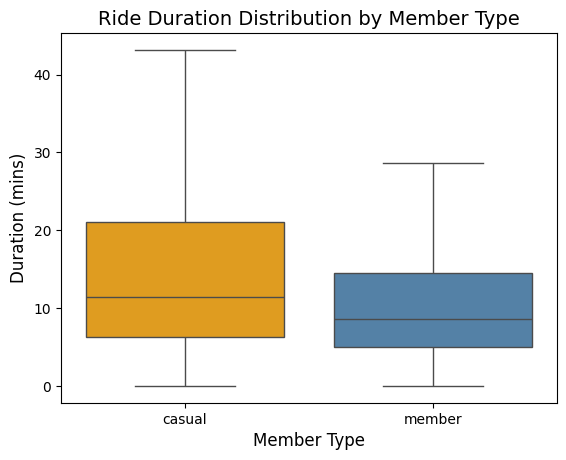

In [16]:
# 4.3.3 Ride duration distribution — boxplot
sns.boxplot(data=df1, x='member_casual', y='ride_duration_mins',
            palette=palette, showfliers=False)                      # showfliers=False hides extreme outliers for a cleaner boxplot
plt.title('Ride Duration Distribution by Member Type', fontsize=14)
plt.xlabel('Member Type', fontsize=12)
plt.ylabel('Duration (mins)', fontsize=12)
plt.show()

In [17]:
# Ride duration statistics by member type
duration_stats = df1.groupby('member_casual')['ride_duration_mins'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('IQR_25', lambda x: x.quantile(0.25)),
    ('IQR_75', lambda x: x.quantile(0.75))
]).round(2)

duration_stats['IQR'] = (duration_stats['IQR_75'] -
                          duration_stats['IQR_25']).round(2)

print(duration_stats)

               mean  median  IQR_25  IQR_75   IQR
member_casual                                    
casual        19.10   11.38    6.30   21.05 14.75
member        11.95    8.58    5.03   14.50  9.47


**Key Findings — Ride Duration:**

Although casual riders represent the minority (36% of rides), they
consistently take longer rides than members:

- **Average duration:** casual riders 19.10 minutes vs members
  11.95 minutes — casual riders ride approximately 7 minutes longer
  on average
- **Median duration:** casual riders 11.38 minutes vs members
  8.58 minutes
- **IQR (middle 50% of rides):** casual riders 6.30–21.05 minutes
  (IQR 14.75) vs members 5.03–14.50 minutes (IQR 9.47) — casual
  riders show a wider and higher distribution

**Key insight:** This suggests casual riders use Cyclistic for **leisure and
exploration** while members use it for **shorter, purpose-driven
trips** such as commuting. This behavioral difference is a key
insight for the marketing strategy.

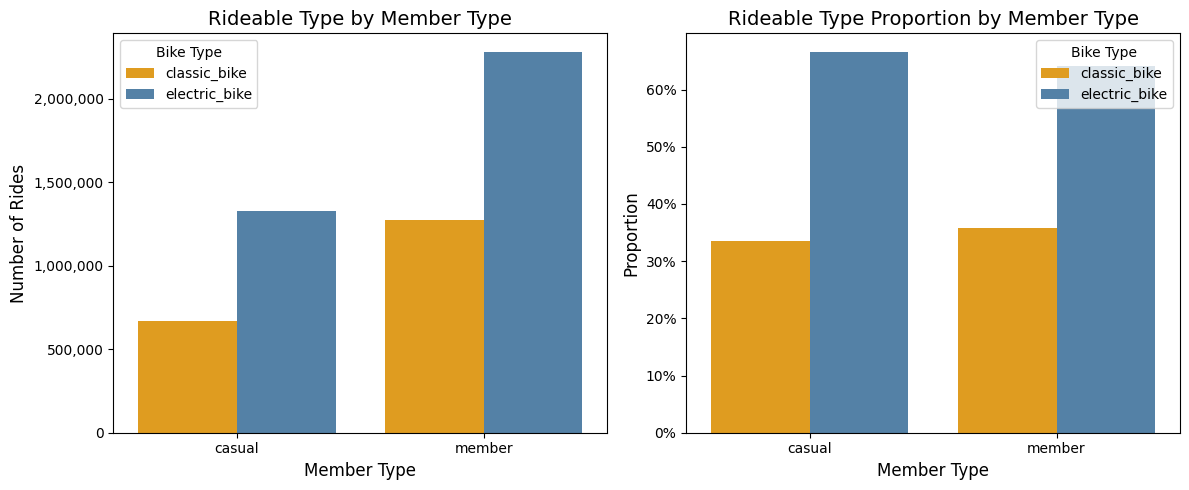

  member_casual  rideable_type    count  proportion
0        casual   classic_bike   667873        0.34
1        casual  electric_bike  1326818        0.67
2        member   classic_bike  1274412        0.36
3        member  electric_bike  2278118        0.64


In [18]:
# 4.3.4 Rideable type preference by member type
rideable_counts = df1.groupby(['member_casual', 'rideable_type']).size().reset_index(name='count')
rideable_props = rideable_counts.copy()
rideable_props['proportion'] = rideable_props.groupby('member_casual')['count'].transform(lambda x: x / x.sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count
sns.barplot(data=rideable_counts, x='member_casual', y='count',
            hue='rideable_type',
            palette={'electric_bike': 'steelblue', 'classic_bike': 'orange'},
            ax=axes[0])
axes[0].set_title('Rideable Type by Member Type', fontsize=14)
axes[0].set_xlabel('Member Type', fontsize=12)
axes[0].set_ylabel('Number of Rides', fontsize=12)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
axes[0].legend(title='Bike Type', fontsize=10)

# Proportion
sns.barplot(data=rideable_props, x='member_casual', y='proportion',
            hue='rideable_type',
            palette={'electric_bike': 'steelblue', 'classic_bike': 'orange'},
            ax=axes[1])
axes[1].set_title('Rideable Type Proportion by Member Type', fontsize=14)
axes[1].set_xlabel('Member Type', fontsize=12)
axes[1].set_ylabel('Proportion', fontsize=12)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
axes[1].legend(title='Bike Type', fontsize=10)

plt.tight_layout()
plt.show()

# Exact figures
print(rideable_props.round(3))

**Key Findings — Rideable Type:**

Electric bikes are the preferred bike type for both groups, but
casual riders show a slightly stronger preference:

- **Casual riders:** 67% electric bike vs 33% classic bike
- **Members:** 64% electric bike vs 36% classic bike

Both groups strongly favour electric bikes, with casual riders
showing a marginally higher preference (67% vs 64%). This is
consistent with the longer average ride duration of casual riders
— electric bikes reduce effort over longer distances, making them
particularly attractive for leisure rides.

In absolute numbers, members take more rides on both bike types
due to their higher overall ride volume.

### 4.4 Temporal Analysis (Python)
    → Rides by hour of day (line chart)
    → Rides by time of day (bar chart)
    → Rides by day of week (bar chart)
    → Rides by month (bar chart)
    → Rides by season (bar chart)
    → Weekday vs weekend comparison (bar chart)

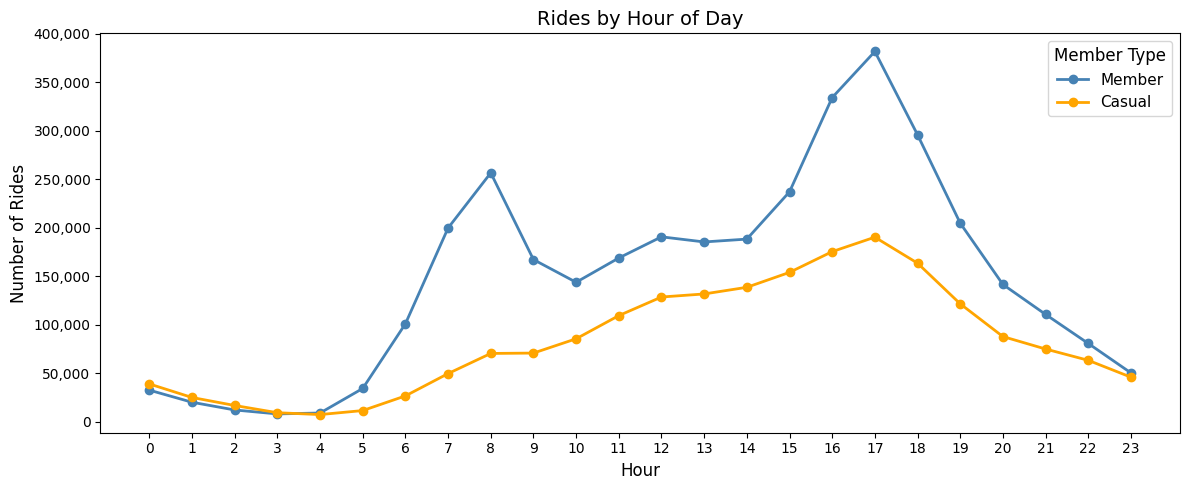

In [19]:
# 4.4.1 Rides by hour of day split by member type
hourly_rides = df1.groupby(['hour', 'member_casual'])['ride_id'].count().reset_index()
hourly_rides.columns = ['hour', 'member_casual', 'count']

plt.figure(figsize=(12, 5))

for group, color in [('member', 'steelblue'), ('casual', 'orange')]:
    data = hourly_rides[hourly_rides['member_casual'] == group]
    plt.plot(data['hour'], data['count'], marker='o',
             color=color, label=group.capitalize(), linewidth=2)

plt.title('Rides by Hour of Day', fontsize=14)
plt.xlabel('Hour', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.xticks(range(0, 24), fontsize=10)
plt.yticks(fontsize=10)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
plt.legend(title='Member Type', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()

**Key Findings — Rides by Hour of Day:**

At night (23:00–04:00) both groups show similarly low activity
(below 50,000 rides) — the only period where their behaviour aligns.

**Members** show a clear **bimodal pattern** consistent with commuting:
- First peak at 08:00 (~255,000 rides) — morning commute
- Midday dip at 10:00 (~150,000 rides)
- Steady growth through the afternoon
- Second and highest peak at 17:00 (~380,000 rides) — evening commute
- Steep decline to ~50,000 rides by 23:00

**Casual riders** show a **unimodal pattern** consistent with leisure:
- Gradual and steady increase from 04:00 onwards
- Single peak at 17:00 (~190,000 rides)
- Steady decline to ~50,000 rides by 23:00

**Key insight:** the bimodal commuter pattern of members vs the
gradual leisure pattern of casual riders is the strongest behavioral
difference identified so far — directly confirming the leisure vs
commuter hypothesis.

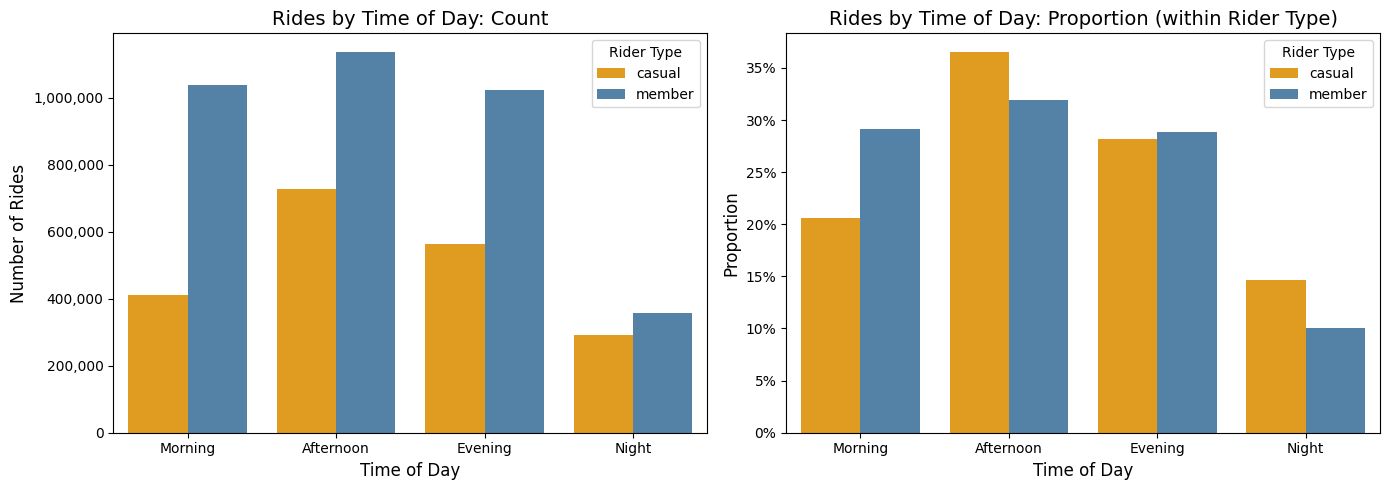

  time_of_day member_casual    count  proportion
0     Morning        casual   411797        0.21
1     Morning        member  1036697        0.29
2   Afternoon        casual   727908        0.36
3   Afternoon        member  1135248        0.32
4     Evening        casual   562830        0.28
5     Evening        member  1023683        0.29
6       Night        casual   292156        0.15
7       Night        member   356902        0.10


In [20]:
# 4.4.2 Rides by Time of Day (count + proportion)
time_of_day_order = ['Morning', 'Afternoon', 'Evening', 'Night']
df1['time_of_day'] = pd.Categorical(df1['time_of_day'], categories=time_of_day_order, ordered=True)

time_of_day_rides = df1.groupby(['time_of_day', 'member_casual'], observed=True).size().reset_index(name='count')
time_of_day_props = time_of_day_rides.copy()
time_of_day_props['proportion'] = time_of_day_props.groupby('member_casual')['count'].transform(lambda x: x / x.sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
sns.barplot(data=time_of_day_rides, x='time_of_day', y='count',
            hue='member_casual', order=time_of_day_order,
            palette={'member': 'steelblue', 'casual': 'orange'},
            ax=axes[0])
axes[0].set_title('Rides by Time of Day: Count', fontsize=14)
axes[0].set_xlabel('Time of Day', fontsize=12)
axes[0].set_ylabel('Number of Rides', fontsize=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
axes[0].legend(title='Rider Type', fontsize=10)

# Proportion
sns.barplot(data=time_of_day_props, x='time_of_day', y='proportion',
            hue='member_casual', order=time_of_day_order,
            palette={'member': 'steelblue', 'casual': 'orange'},
            ax=axes[1])
axes[1].set_title('Rides by Time of Day: Proportion (within Rider Type)', fontsize=14)
axes[1].set_xlabel('Time of Day', fontsize=12)
axes[1].set_ylabel('Proportion', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
axes[1].legend(title='Rider Type', fontsize=10)

plt.tight_layout()
plt.show()

# Exact figures
print(time_of_day_props.round(3))

**Key Findings — Rides by Time of Day:**

**Members** show a **clear commute-shaped pattern across the day**:
- Highest in Afternoon (approx. 1,140,000 rides) and Morning (approx. 1,040,000 rides) — representing nearly 2/3 of all rides during a day (61%) and consistent with commuting to and from work
- Evening remains strong (approx. 1,025,000 rides), only slightly below the morning/afternoon peaks
- Drops sharply at Night (approx. 360,000 rides) — the lowest point of the day, representing only 10% of daily rides
- Even at its lowest, member volume stays well above casual's night-time floor

This confirms members' daily rhythm aligns closely with **standard work-day hours**, tapering off once the working day ends.

**Casual riders** show a **similarly shaped but more compressed pattern**:
- Builds from Morning (approx. 410,000 rides) to a peak in Afternoon (approx. 730,000 rides) forming together more than half of all rides during a day (57%)
- Evening remains elevated (approx. 565,000 rides) before a steep drop at Night (approx. 290,000 rides)
- Morning is notably weaker relative to members, consistent with casual riders not commuting at the same rate

This confirms casual usage still favors daytime and early-evening hours, but **lacks the pronounced morning commute spike** seen in members.

**Key insight:** the casual-to-member ratio is lowest in the Morning (411,797 / 1,036,697 = 39.7%) — the clearest sign of member-dominated commuting — and rises steadily through Afternoon (64.1%) and Evening (55.0%), peaking at Night (81.9%), even though night-time volumes for both groups are the smallest of the day. This suggests casual riders' relative presence grows as the day progresses, even as absolute ride counts fall, reinforcing that member demand is anchored to structured commute times while casual demand is more flexible and spread across the day.

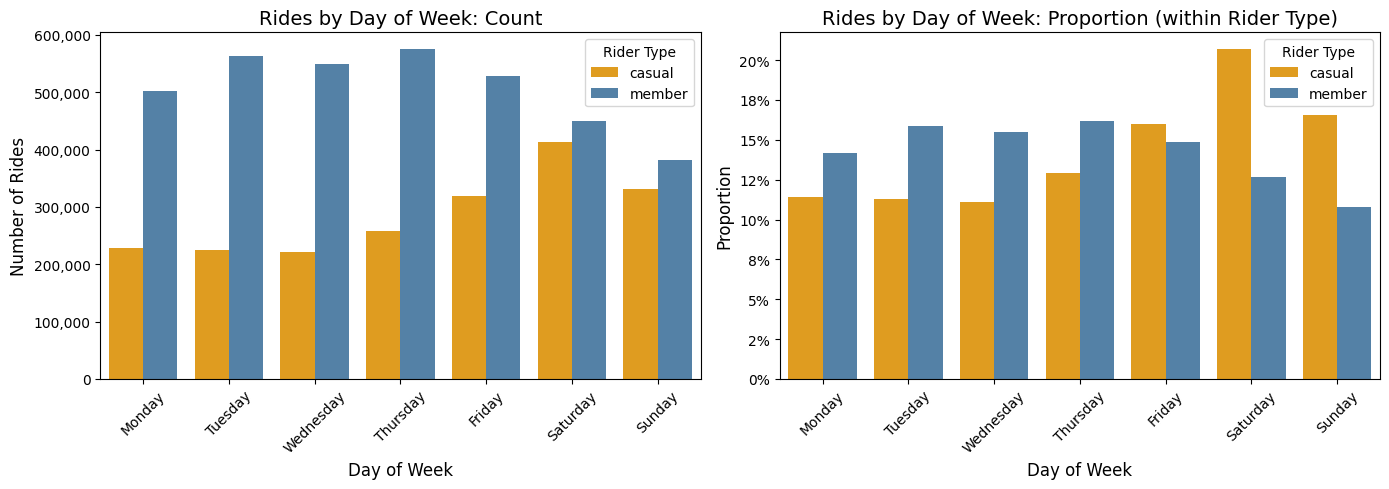

   day_of_week member_casual   count  proportion
0       Monday        casual  227728        0.11
1       Monday        member  502647        0.14
2      Tuesday        casual  225145        0.11
3      Tuesday        member  562947        0.16
4    Wednesday        casual  221084        0.11
5    Wednesday        member  550015        0.15
6     Thursday        casual  257500        0.13
7     Thursday        member  575852        0.16
8       Friday        casual  319272        0.16
9       Friday        member  528849        0.15
10    Saturday        casual  413100        0.21
11    Saturday        member  450048        0.13
12      Sunday        casual  330862        0.17
13      Sunday        member  382172        0.11


In [21]:
# 4.4.3 Rides by Day of Week (count + proportion)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df1['day_of_week'] = pd.Categorical(df1['day_of_week'], categories=day_order, ordered=True)

day_of_week_rides = df1.groupby(['day_of_week', 'member_casual'], observed=True).size().reset_index(name='count')
day_of_week_props = day_of_week_rides.copy()
day_of_week_props['proportion'] = day_of_week_props.groupby('member_casual')['count'].transform(lambda x: x / x.sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
sns.barplot(data=day_of_week_rides, x='day_of_week', y='count',
            hue='member_casual', order=day_order,
            palette={'member': 'steelblue', 'casual': 'orange'},
            ax=axes[0])
axes[0].set_title('Rides by Day of Week: Count', fontsize=14)
axes[0].set_xlabel('Day of Week', fontsize=12)
axes[0].set_ylabel('Number of Rides', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
axes[0].legend(title='Rider Type', fontsize=10)

# Proportion
sns.barplot(data=day_of_week_props, x='day_of_week', y='proportion',
            hue='member_casual', order=day_order,
            palette={'member': 'steelblue', 'casual': 'orange'},
            ax=axes[1])
axes[1].set_title('Rides by Day of Week: Proportion (within Rider Type)', fontsize=14)
axes[1].set_xlabel('Day of Week', fontsize=12)
axes[1].set_ylabel('Proportion', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
axes[1].legend(title='Rider Type', fontsize=10)

plt.tight_layout()
plt.show()

# Exact figures
print(day_of_week_props.round(3))

**Key Findings — Rides by Day of Week:**

**Casual riders** show a clear **weekend-oriented pattern**:
- Relatively stable weekday activity (Mon–Thu: 220,000–260,000 rides)
- Gradual increase on Friday (~320,000 rides)
- Peak on Saturday (~415,000 rides) — highest day for casual riders, forming 21% of their weekly rides
- Slight decrease on Sunday (~330,000 rides) — second highest frequency with 17%
- Together, Saturday and Sunday account for ~37% of all casual rides — over a third of casual volume concentrated in just two days

This confirms casual riders primarily use Cyclistic for **leisure
and recreational activities** concentrated on weekends.

**Members** show a clear **weekday-oriented pattern**:
- High and stable weekday activity (Mon–Thu: 500,000–575,000 rides)
- Thursday is the busiest day (~575,000 rides)
- Gradual decline from Friday onwards
- Weekend activity drops to 450,000 (Saturday) and 385,000 (Sunday)

This confirms members primarily use Cyclistic for **commuting and
work-related trips** during the working week.

**Key insight:** the casual-to-member ratio is lowest on Tuesday (225,145 / 562,947 = 40.0%) and highest on Saturday (413,100 / 450,048 = 91.8%) and Sunday (86.6%) — on weekends, casual riders very nearly match members in absolute volume. This is the clearest confirmation of the commuter-vs-leisure divide yet.

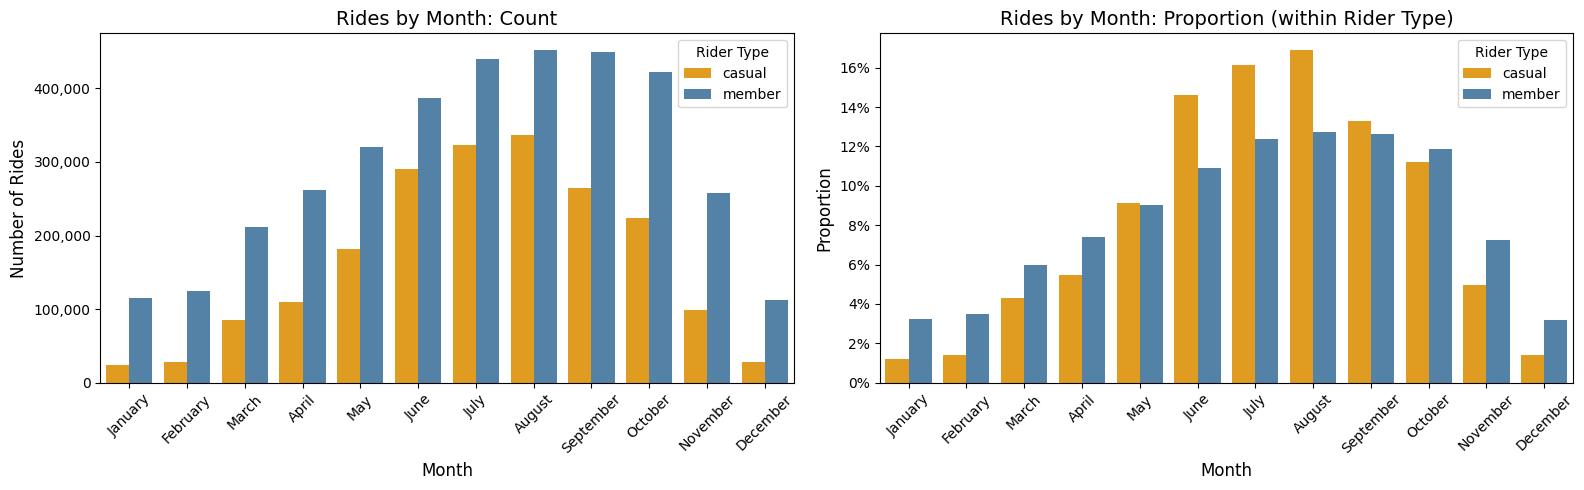

   month_name member_casual   count  proportion
0     January        casual   24076        0.01
1     January        member  114506        0.03
2    February        casual   27709        0.01
3    February        member  124123        0.04
4       March        casual   85658        0.04
5       March        member  212225        0.06
6       April        casual  108967        0.06
7       April        member  262094        0.07
8         May        casual  182256        0.09
9         May        member  319748        0.09
10       June        casual  291111        0.15
11       June        member  386703        0.11
12       July        casual  322488        0.16
13       July        member  439963        0.12
14     August        casual  337236        0.17
15     August        member  452350        0.13
16  September        casual  264759        0.13
17  September        member  449199        0.13
18    October        casual  223562        0.11
19    October        member  421915     

In [22]:
# 4.4.4 Rides by Month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df1['month_name'] = pd.Categorical(df1['month_name'], categories=month_order, ordered=True)

monthly_rides = df1.groupby(['month_name', 'member_casual'], observed=True).size().reset_index(name='count')
monthly_props = monthly_rides.copy()
monthly_props['proportion'] = monthly_props.groupby('member_casual')['count'].transform(lambda x: x / x.sum())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count
sns.barplot(data=monthly_rides, x='month_name', y='count',
            hue='member_casual', order=month_order,
            palette={'member': 'steelblue', 'casual': 'orange'},
            ax=axes[0])
axes[0].set_title('Rides by Month: Count', fontsize=14)
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Number of Rides', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
axes[0].legend(title='Rider Type', fontsize=10)

# Proportion
sns.barplot(data=monthly_props, x='month_name', y='proportion',
            hue='member_casual', order=month_order,
            palette={'member': 'steelblue', 'casual': 'orange'},
            ax=axes[1])
axes[1].set_title('Rides by Month: Proportion (within Rider Type)', fontsize=14)
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Proportion', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
axes[1].legend(title='Rider Type', fontsize=10)

plt.tight_layout()
plt.show()

# Exact figures
print(monthly_props.round(3))

**Key Findings — Rides by Month:**

**Members** show a clear **year-round, commuter-consistent pattern**:
- Never drop below ~110,000 rides, even in the depths of winter (Dec–Feb: ~113,000–125,000 rides)
- Steady climb from spring into summer, peaking in August (~450,000 rides)
- Elevated activity persists into fall (Sep–Oct: ~421,000–449,000 rides) before tapering
- Overall range is roughly 4x from trough to peak

This confirms members rely on Cyclistic for **routine, weather-resilient trips** — most likely commuting — that continue regardless of season.

**Casual riders** show a sharply **seasonal, leisure-driven pattern**:
- Winter activity is minimal (Dec–Feb: ~24,000–28,000 rides)
- Rapid buildup through spring, reaching similar peak timing as members (Jun–Aug: ~291,000–337,000 rides); additional insight: these three months alone account for nearly half (approx. 48%) of all casual riders' annual volume — a striking concentration
- Sharper drop-off after August compared to members (Aug → Oct: ~335,000 → ~224,000 rides)
- Overall range is roughly 13x from trough to peak — over three times the seasonal swing seen in members

This confirms casual riders primarily use Cyclistic for **leisure and fair-weather recreational activities**, with usage heavily concentrated in the summer months.

**Key insight:** the casual-to-member ratio bottoms at 21.0% in January (24,076 / 114,506) and peaks at 75.3% in June (291,111 / 386,703) — narrowly ahead of July (73.3%) and August (74.5%). Notably, the ratio peaks slightly *before* absolute casual/member volumes do, pointing to early summer (June) as a distinct window worth calling out for conversion campaigns, alongside the shoulder months already identified.

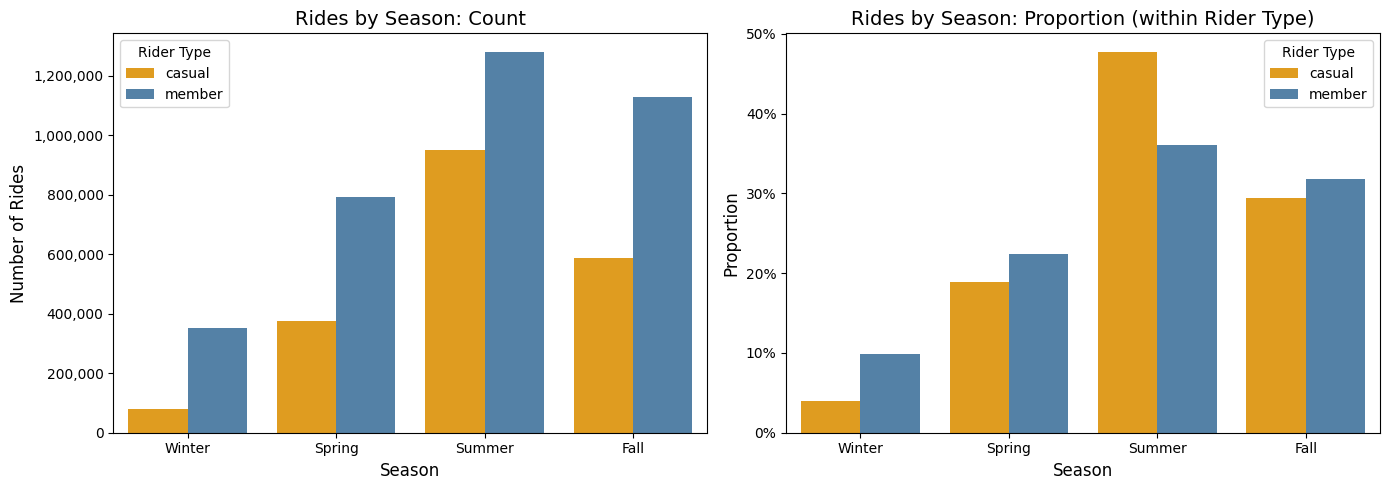

   season member_casual    count  proportion
0  Winter        casual    79813        0.04
1  Winter        member   351053        0.10
2  Spring        casual   376881        0.19
3  Spring        member   794067        0.22
4  Summer        casual   950835        0.48
5  Summer        member  1279016        0.36
6    Fall        casual   587162        0.29
7    Fall        member  1128394        0.32


In [23]:
# 4.4.5 Rides by Season (count + proportion)
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
df1['season'] = pd.Categorical(df1['season'], categories=season_order, ordered=True)

seasonal_rides = df1.groupby(['season', 'member_casual'], observed=True).size().reset_index(name='count')
seasonal_props = seasonal_rides.copy()
seasonal_props['proportion'] = seasonal_props.groupby('member_casual')['count'].transform(lambda x: x / x.sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count
sns.barplot(data=seasonal_rides, x='season', y='count',
            hue='member_casual', order=season_order,
            palette={'member': 'steelblue', 'casual': 'orange'},
            ax=axes[0])
axes[0].set_title('Rides by Season: Count', fontsize=14)
axes[0].set_xlabel('Season', fontsize=12)
axes[0].set_ylabel('Number of Rides', fontsize=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
axes[0].legend(title='Rider Type', fontsize=10)

# Proportion
sns.barplot(data=seasonal_props, x='season', y='proportion',
            hue='member_casual', order=season_order,
            palette={'member': 'steelblue', 'casual': 'orange'},
            ax=axes[1])
axes[1].set_title('Rides by Season: Proportion (within Rider Type)', fontsize=14)
axes[1].set_xlabel('Season', fontsize=12)
axes[1].set_ylabel('Proportion', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
axes[1].legend(title='Rider Type', fontsize=10)

plt.tight_layout()
plt.show()

# Exact figures
print(seasonal_props.round(3))

**Key Findings — Rides by Season:**

**Members** show **consistently high ridership across all warmer seasons**:
- Lowest in Winter (approx. 350,000 rides), still far above casual's winter floor
- Rises through Spring (approx. 795,000 rides) to a peak in Summer (~1,270,000 rides), representing more than 1/3 of all rides (36%)
- Remains elevated in Fall (approx. 1,130,000 rides) — only a modest drop from Summer and still forming approx. 1/3 of all rides (32%)
- Overall range is roughly 3.5x from trough to peak

This confirms members maintain **strong ridership well beyond peak summer**, consistent with commuting behavior that persists as long as conditions remain reasonably rideable.

**Casual riders** show a **much steeper seasonal concentration**:
- Winter activity is minimal (approx. 75,000 rides)
- Rises through Spring (approx. 375,000 rides) to a Summer peak (~950,000 rides) where nearly half of all rides take place (48%)
- Drops off sharply in Fall (approx. 585,000 rides) — a much steeper decline than members but still forming 29% of all rides
- Overall range is roughly 12x from trough to peak — more than 3x the seasonal swing seen in members

This confirms casual riders' usage is **tightly bound to warm-weather leisure conditions**, dropping off quickly once summer ends.

**Key insight:** the casual-to-member ratio rises from 22.7% in Winter (79,813 / 351,053) to 47.5% (Spring) to 74.3% (Summer), then falls back to 52.0% in Fall — nearly matching Spring's level. This shows casual demand does not just fade gradually; it collapses right after the summer peak, while members sustain a longer "high season." This reinforces the finding from the monthly analysis and further supports targeting conversion campaigns in Spring and early Fall, when casual volume is still meaningful but member-level loyalty has not yet formed.

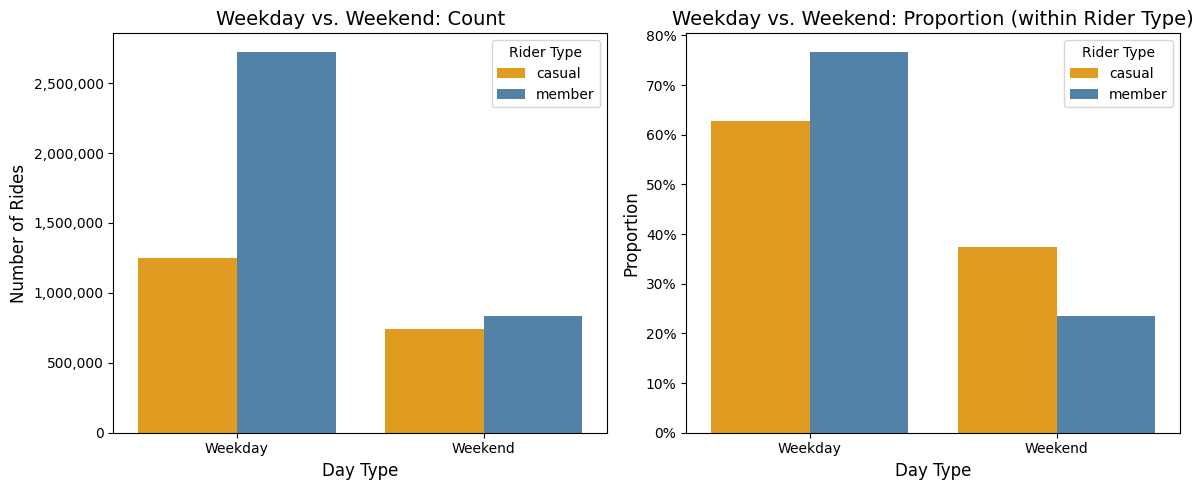

  day_type member_casual    count  proportion
0  Weekday        casual  1250729        0.63
1  Weekday        member  2720310        0.77
2  Weekend        casual   743962        0.37
3  Weekend        member   832220        0.23


In [24]:
# 4.4.7 Weekday vs. Weekend (count + proportion)
day_type_order = ['Weekday', 'Weekend']
df1['day_type'] = pd.Categorical(df1['day_type'], categories=day_type_order, ordered=True)

day_type_rides = df1.groupby(['day_type', 'member_casual'], observed=True).size().reset_index(name='count')
day_type_props = day_type_rides.copy()
day_type_props['proportion'] = day_type_props.groupby('member_casual')['count'].transform(lambda x: x / x.sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count
sns.barplot(data=day_type_rides, x='day_type', y='count',
            hue='member_casual', order=day_type_order,
            palette={'member': 'steelblue', 'casual': 'orange'},
            ax=axes[0])
axes[0].set_title('Weekday vs. Weekend: Count', fontsize=14)
axes[0].set_xlabel('Day Type', fontsize=12)
axes[0].set_ylabel('Number of Rides', fontsize=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
axes[0].legend(title='Rider Type', fontsize=10)

# Proportion
sns.barplot(data=day_type_props, x='day_type', y='proportion',
            hue='member_casual', order=day_type_order,
            palette={'member': 'steelblue', 'casual': 'orange'},
            ax=axes[1])
axes[1].set_title('Weekday vs. Weekend: Proportion (within Rider Type)', fontsize=14)
axes[1].set_xlabel('Day Type', fontsize=12)
axes[1].set_ylabel('Proportion', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
axes[1].legend(title='Rider Type', fontsize=10)

plt.tight_layout()
plt.show()

# Exact figures
print(day_type_props.round(3))

**Key Findings — Rides by Weekday vs. Weekend:**

**Members** show **a significantly higher number of rides during weekdays**:
- Weekday rides (approx. 2,720,000 rides) represent more than 3/4 of all rides (77%)
- Weekend rides remain significantly lower (approx. 832,000 rides), only forming around 1/4 of all rides (23%)

This reveals that members are **strong weekday-riders**, consistent with job-related behavior like commuting.

**Casual riders** show a **more balanced weekday-vs-weekend riding behavior**:
- Weekday activity is higher (approx. 1,251,000 rides), representing nearly 2/3 of all rides (63%)
- This drops on weekends (approx. 744,000 rides) to a similar absolute level compared to members, however on a higher relative scale of more than 1/3 of all rides (37%)

This confirms that members show a **strong weekday work-related usage behavior**, whereas casual riders show a more balanced riding pattern.

**Key insight:** the casual-to-member ratio is 46.0% on Weekdays (1,251,000 / 2,720,000) versus 89.4% on Weekends (744,000 / 832,000) — nearly double. This aggregated view confirms the pattern seen in the day-of-week breakdown, where the ratio ranged from a low of 40.0% (Tuesday) to a high of 91.8% (Saturday): on weekends, casual riders very nearly match members in absolute volume, while on weekdays members dominate by more than 2-to-1. This is the clearest single statistic yet supporting the commuter-vs-leisure divide.

### 4.5 Statistical Visualizations (R/ggplot2)
    → ggplot2 publication-quality versions of key charts
    → Focus on the most impactful two visualizations

In the following section, R is used instead of Python for the following reasons:

* **Certificate alignment** — the Cyclistic case study is the official capstone for the R-based track of the certificate program
* **ggplot2's layered grammar** — features like `facet_wrap()` (small multiples by season/day-type in one call) and `stat_summary()`/`geom_smooth()` for statistical overlays are more concise in ggplot2 than seaborn/matplotlib would allow
* **Portfolio breadth** — lastly, this analysis demonstrates the variety and advantages of different programming languages for data analysis, such as Python and R

In [25]:
# Pre-aggregate in pandas — keeps the data crossing into R small and fast
hourly_by_day_py = df1.groupby(['day_of_week', 'hour', 'member_casual'], observed=True).size().reset_index(name='count')
monthly_duration_py = df1.groupby(['month_name', 'member_casual'], observed=True)['ride_duration_mins'].mean().reset_index(name='avg_duration')

Learn more about the underlying theory at https://ggplot2-book.org/


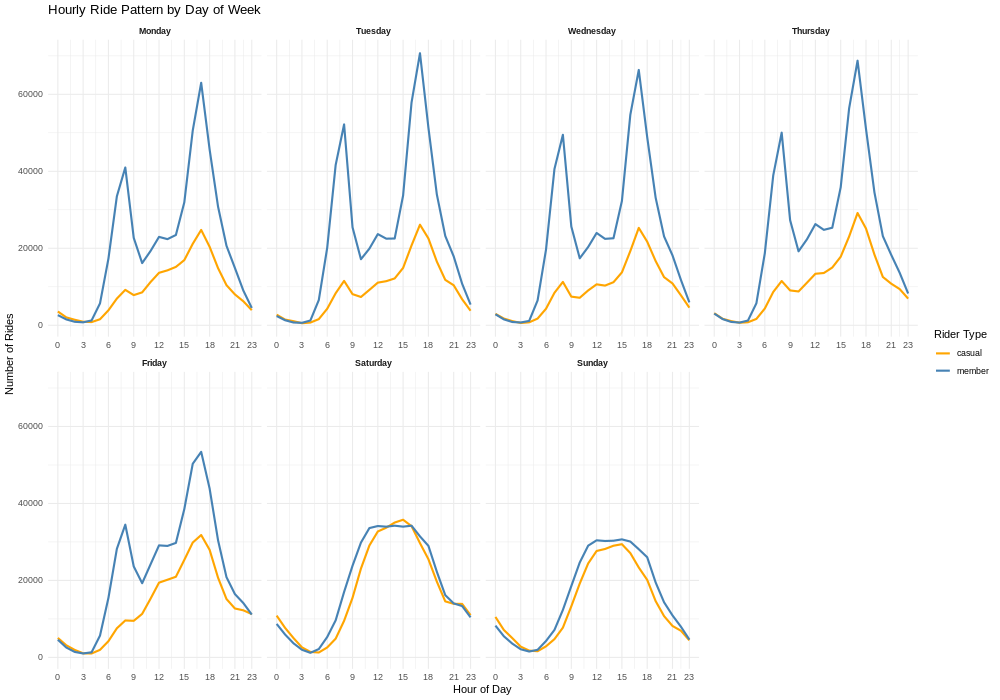

In [26]:
%%R -i hourly_by_day_py -w 1000 -h 700
library(ggplot2)

day_order <- c('Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday')
hourly_by_day_py$day_of_week <- factor(hourly_by_day_py$day_of_week, levels = day_order)

ggplot(hourly_by_day_py, aes(x = hour, y = count, color = member_casual)) +
  geom_line(linewidth = 1) +
  facet_wrap(~ day_of_week, ncol = 4, scales = "free_x") +
  scale_color_manual(values = c("member" = "steelblue", "casual" = "orange")) +
  scale_x_continuous(breaks = c(0, 3, 6, 9, 12, 15, 18, 21, 23), labels = c("0", "3", "6", "9", "12", "15", "18", "21", "23")) +
  labs(title = "Hourly Ride Pattern by Day of Week",
       x = "Hour of Day", y = "Number of Rides", color = "Rider Type") +
  theme_minimal() +
  theme(strip.text = element_text(face = "bold"),
        axis.text.x = element_text(size = 9))

**Key Findings — Hourly Ride Pattern by Day of Week (facet_wrap):**

**Weekdays (Monday-Friday)**
- Members show a **clear bimodal commute signature**: a sharp morning peak (around 8am) and an even sharper evening peak (around 5pm), with a smaller midday plateau in between
- Casual riders on weekdays show a much flatter profile — a modest morning bump and a broader, lower afternoon/evening rise, with no distinct commute-hour spikes

**Weekends (Saturday-Sunday)**
- Demonstrate a **fundamentally different, unimodal shape for both groups**: a single broad peak in early-to-mid afternoon (between 1-3pm)
- Compared to weekdays, member and casual lines running much closer together

**Key insight:** The hourly riding pattern of members shifts from bimodal (commute-driven) on weekdays to unimodal (leisure-driven) on weekends, converging with casual riders' pattern. This is the clearest visual evidence yet that members use Cyclistic for two distinct purposes depending on the day: commuting on weekdays, leisure on weekends — an insight the aggregated weekday/weekend bar chart was not able to show.

`geom_smooth()` using formula = 'y ~ x'


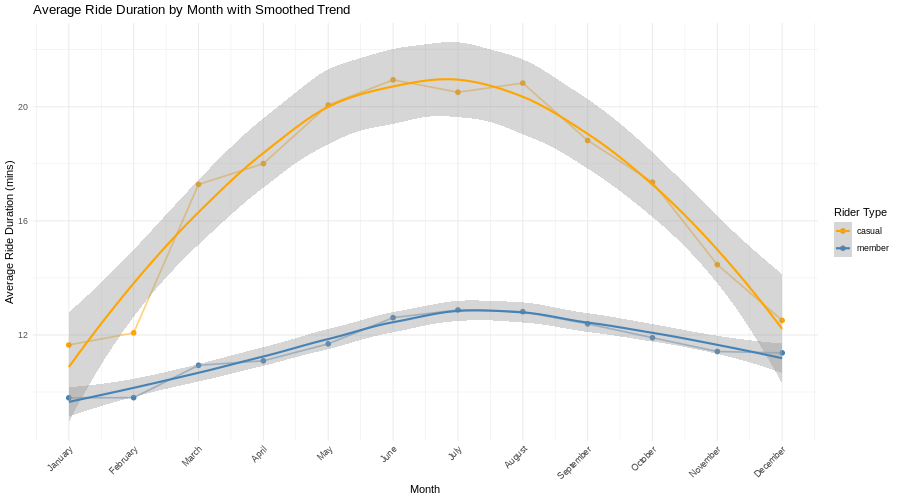

In [27]:
%%R -i monthly_duration_py -w 900 -h 500
library(ggplot2)

month_order <- c('January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November', 'December')
monthly_duration_py$month_name <- factor(monthly_duration_py$month_name, levels = month_order)
monthly_duration_py$month_num <- as.numeric(monthly_duration_py$month_name)

ggplot(monthly_duration_py, aes(x = month_num, y = avg_duration, color = member_casual)) +
  geom_point(size = 2) +
  geom_line(linewidth = 0.8, alpha = 0.5) +
  geom_smooth(se = TRUE, method = "loess") +
  scale_color_manual(values = c("member" = "steelblue", "casual" = "orange")) +
  scale_x_continuous(breaks = 1:12, labels = month_order) +
  labs(title = "Average Ride Duration by Month with Smoothed Trend",
       x = "Month", y = "Average Ride Duration (mins)", color = "Rider Type") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

**Key Findings — Average Ride Duration by Month with Smoothed Trend:**

- **Casual riders** take substantially longer trips than members in every month, with average duration ranging from ~10-12 mins (Dec-Feb) to a peak of ~21-22 mins (Jun-Jul) — roughly double their winter baseline.

- **Members** show the same seasonal shape but at a much lower, narrower range: ~10-11 mins (Dec-Feb) rising to ~13 mins (Jun-Jul) — a much smaller relative swing than casual riders.

**Key insight:** this chart introduces a variable the count-based charts could not show — **trip length**, not just trip frequency. Casual riders do not just ride more in summer; they also ride nearly twice as long per trip as members, consistent with leisure/sightseeing use rather than point-to-point commuting. The parallel seasonal shape (both peaking in summer) suggests weather affects trip duration for both groups.

### 4.6 Geospatial Analysis (Python)
    → Top 10 start stations by member type (bar chart)
    → Top 10 end stations by member type (bar chart)
    → Folium heatmap of ride start locations
    → Folium map of top stations

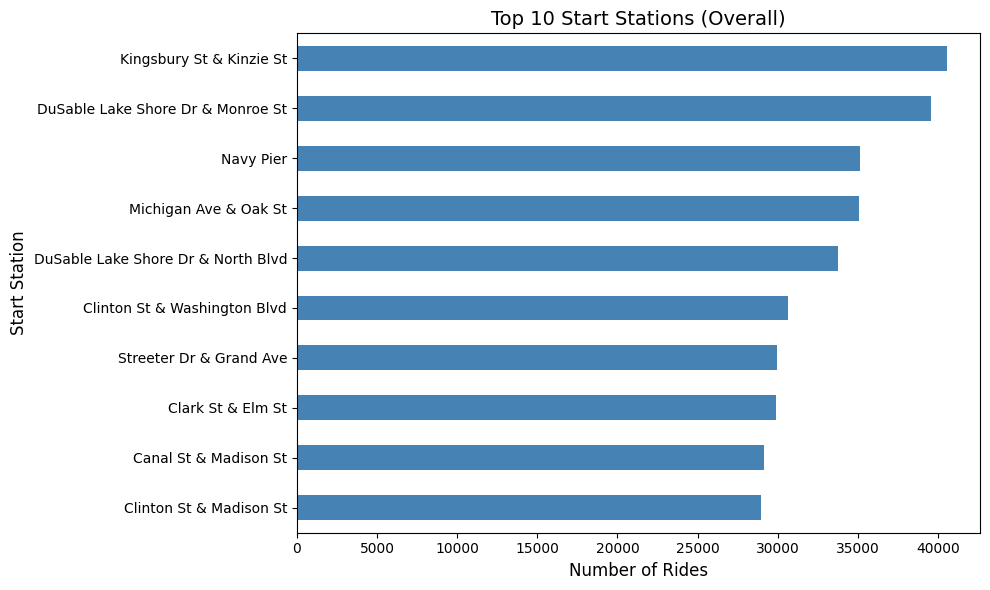

                   start_station_name  count  proportion
0            Kingsbury St & Kinzie St  40587        0.01
1   DuSable Lake Shore Dr & Monroe St  39537        0.01
2                           Navy Pier  35099        0.01
3               Michigan Ave & Oak St  35063        0.01
4  DuSable Lake Shore Dr & North Blvd  33757        0.01
5        Clinton St & Washington Blvd  30639        0.01
6             Streeter Dr & Grand Ave  29977        0.01
7                   Clark St & Elm St  29878        0.01
8               Canal St & Madison St  29169        0.01
9             Clinton St & Madison St  28967        0.01


In [28]:
# Top 10 start stations by total ride volume (overall, no split)
top_10_start_stations = df1['start_station_name'].value_counts().iloc[:10]

plt.figure(figsize=(10, 6))
top_10_start_stations.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Start Stations (Overall)', fontsize=14)
plt.xlabel('Number of Rides', fontsize=12)
plt.ylabel('Start Station', fontsize=12)
plt.tight_layout()
plt.show()

# Table: top 10 stations with count and share of ALL rides (not just top 10)
total_rides = len(df1)

top_10_start_table = top_10_start_stations.reset_index()
top_10_start_table.columns = ['start_station_name', 'count']
top_10_start_table['proportion'] = top_10_start_table['count'] / total_rides

# Exact figures
print(top_10_start_table.round(3))

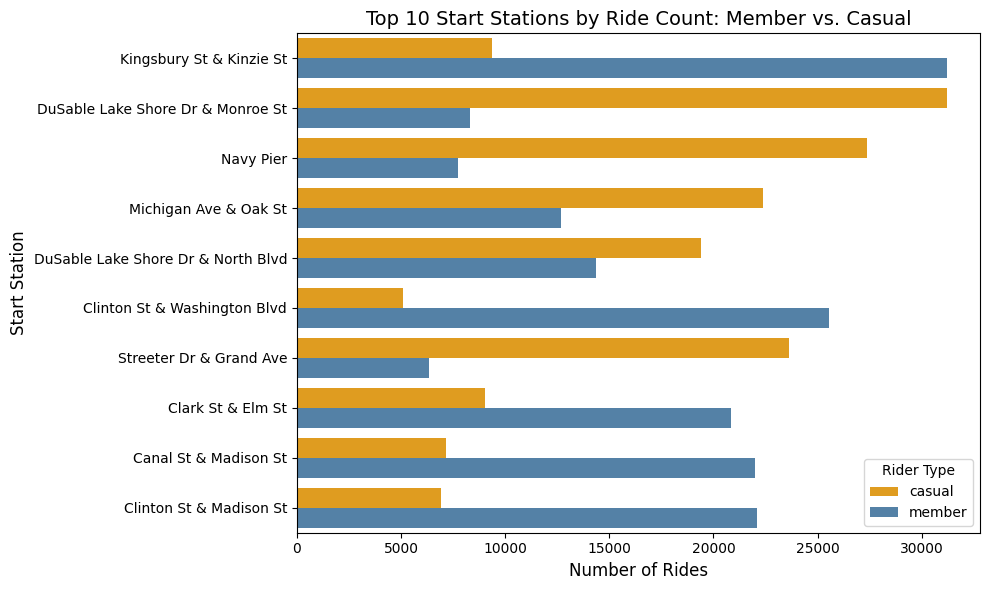

                    start_station_name member_casual  count  proportion
0                Canal St & Madison St        casual   7153        0.24
1                Canal St & Madison St        member  22016        0.76
2                    Clark St & Elm St        casual   9036        0.30
3                    Clark St & Elm St        member  20842        0.70
4              Clinton St & Madison St        casual   6895        0.24
5              Clinton St & Madison St        member  22072        0.76
6         Clinton St & Washington Blvd        casual   5077        0.17
7         Clinton St & Washington Blvd        member  25562        0.83
8    DuSable Lake Shore Dr & Monroe St        casual  31236        0.79
9    DuSable Lake Shore Dr & Monroe St        member   8301        0.21
10  DuSable Lake Shore Dr & North Blvd        casual  19389        0.57
11  DuSable Lake Shore Dr & North Blvd        member  14368        0.43
12            Kingsbury St & Kinzie St        casual   9385     

In [29]:
# Filter to just those stations, then break down by member type
top_10_start_rides = df1[df1['start_station_name'].isin(top_10_start_stations.index)].groupby(
    ['start_station_name', 'member_casual'], observed=True
).size().reset_index(name='count')

top_10_start_props = top_10_start_rides.copy()
top_10_start_props['proportion'] = top_10_start_props.groupby('start_station_name')['count'].transform(lambda x: x / x.sum())

# Plot: top 10 start stations, split by rider type (horizontal)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_start_rides, y='start_station_name', x='count',
            hue='member_casual', order=top_10_start_stations.index,
            palette={'member': 'steelblue', 'casual': 'orange'})
plt.title('Top 10 Start Stations by Ride Count: Member vs. Casual', fontsize=14)
plt.ylabel('Start Station', fontsize=12)
plt.xlabel('Number of Rides', fontsize=12)
plt.legend(title='Rider Type')
plt.tight_layout()
plt.show()

# Exact figures
print(top_10_start_props.round(3))

**Key Findings — Top 10 Start Stations (Overall):**

**Overall ridership is highly distributed**, not concentrated at a few dominant hubs:
- Most frequented station: Kingsbury St & Kinzie St (40,587 rides)
- Despite being the single busiest station, this represents only ~0.1% of all 5,547,221 rides
- No station among the top 10 individually exceeds ~1% of total ride volume

**The top 10 overall stations are not equally used by both rider groups**:
- Kingsbury St & Kinzie St — the busiest station overall — is heavily member-dominated (9,385 casual vs. 31,202 member rides, a 77% member share)
- DuSable Lake Shore Dr & Monroe St sits at the opposite extreme (79% casual)

**Key insight:** the imbalance at individual stations (e.g., 77% member at Kingsbury St & Kinzie St vs. 79% casual at DuSable Lake Shore Dr & Monroe St) suggests that member and casual riders have fundamentally different starting-point preferences, not just different overall volumes. This is assessed directly in the following chart, where top stations are ranked independently within each rider group rather than filtered from a shared overall top 10.

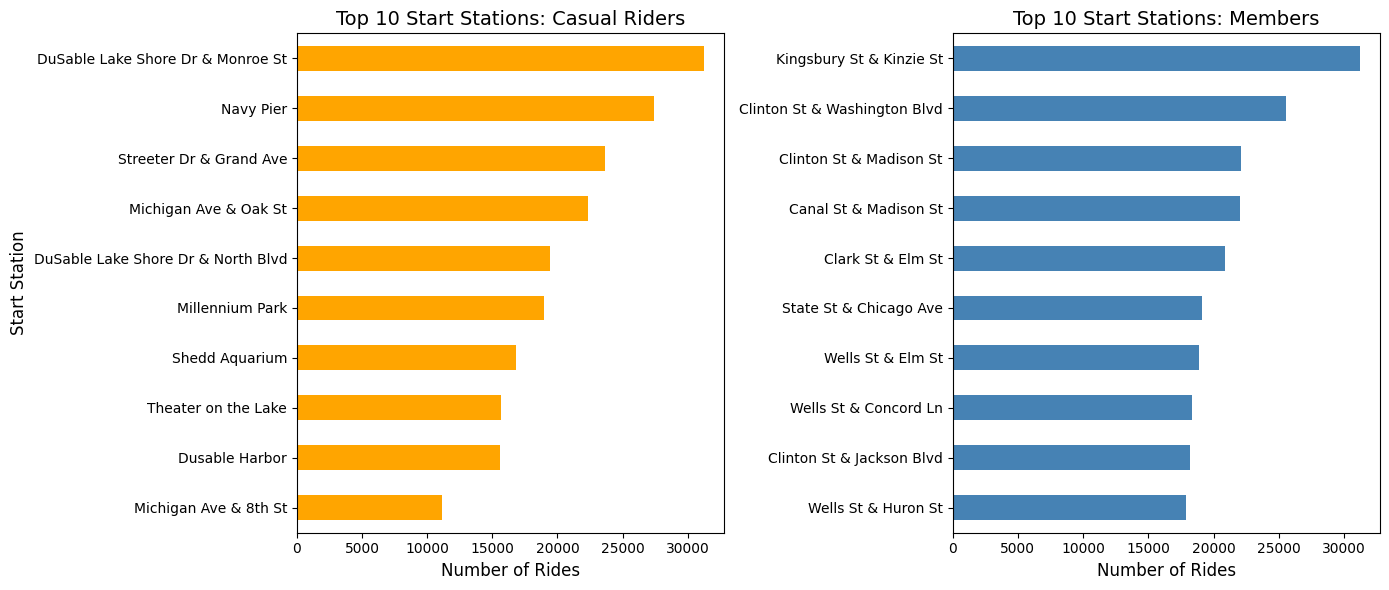

Casual top 10:
                    start_station_name  count  proportion_of_casual_total
0   DuSable Lake Shore Dr & Monroe St  31236                        0.02
1                           Navy Pier  27381                        0.01
2             Streeter Dr & Grand Ave  23614                        0.01
3               Michigan Ave & Oak St  22362                        0.01
4  DuSable Lake Shore Dr & North Blvd  19389                        0.01
5                     Millennium Park  18999                        0.01
6                      Shedd Aquarium  16813                        0.01
7                 Theater on the Lake  15663                        0.01
8                      Dusable Harbor  15572                        0.01
9               Michigan Ave & 8th St  11166                        0.01

Member top 10:
              start_station_name  count  proportion_of_member_total
0      Kingsbury St & Kinzie St  31202                        0.01
1  Clinton St & Washington Blv

In [30]:
# Top 10 start stations, computed independently within each rider type
casual_top_10 = df1[df1['member_casual'] == 'casual']['start_station_name'].value_counts().iloc[:10]
member_top_10 = df1[df1['member_casual'] == 'member']['start_station_name'].value_counts().iloc[:10]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

casual_top_10.sort_values().plot(kind='barh', color='orange', ax=axes[0])
axes[0].set_title('Top 10 Start Stations: Casual Riders', fontsize=14)
axes[0].set_xlabel('Number of Rides', fontsize=12)
axes[0].set_ylabel('Start Station', fontsize=12)

member_top_10.sort_values().plot(kind='barh', color='steelblue', ax=axes[1])
axes[1].set_title('Top 10 Start Stations: Members', fontsize=14)
axes[1].set_xlabel('Number of Rides', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Exact figures
casual_top_10_table = casual_top_10.reset_index()
casual_top_10_table.columns = ['start_station_name', 'count']
casual_top_10_table['proportion_of_casual_total'] = casual_top_10_table['count'] / (df1['member_casual'] == 'casual').sum()

member_top_10_table = member_top_10.reset_index()
member_top_10_table.columns = ['start_station_name', 'count']
member_top_10_table['proportion_of_member_total'] = member_top_10_table['count'] / (df1['member_casual'] == 'member').sum()

print("Casual top 10:\n", casual_top_10_table.round(3))
print("\nMember top 10:\n", member_top_10_table.round(3))

**Key Findings — Top 10 Start Stations by Rider Type:**

**Casual riders** show a clear preference for **touristic and lakefront locations**:
- Most-used station: DuSable Lake Shore Dr & Monroe St (31,236 rides, ~2% of all casual rides)
- Followed by Navy Pier (27,381 rides) and Streeter Dr & Grand Ave (23,614 rides)
- Remaining top stations include Michigan Ave & Oak St, Millennium Park, Shedd Aquarium, and Theater on the Lake — all recognizable tourist/recreational landmarks

**Members** show a clear preference for **central business-district stations**:
- Most-used station: Kingsbury St & Kinzie St (31,202 rides)
- Followed by Clinton St & Washington Blvd (25,562 rides) and Clinton St & Madison St (22,072 rides)
- Remaining top stations (Canal St & Madison St, Clark St & Elm St, Wells St & Elm St) cluster around the Loop and near-transit corridors, consistent with office and commuter hubs

*Note: the dataset does not label stations by land-use type — "touristic" and "business-district" classifications above are based on general knowledge of Chicago geography and landmark names, not a column in the data. For that reason, a geospatial analysis is carried out in the final EDA section. Both outcomes, the Folium heatmap of start locations and the Folium map of top stations, support the interpretations as they show the highest ride-density is concentrated along the lakefront and downtown corridor, casual-dominant stations are located at or near Lake Michigan and member-dominant stations are located more centrally towards the business district. A more rigorous approach would join station coordinates against an external land-use or points-of-interest dataset (e.g., OpenStreetMap) to classify stations programmatically.*

**Key insight:** the two rider groups' top 10 stations barely overlap which corresponds with the leisure-vs-commuter divide seen throughout this analysis. Casual riders prefer start stations at the lakefront and cultural landmarks (Navy Pier, Millennium Park, Shedd Aquarium), while members concentrate around the Loop's business core and transit hubs. This spatial pattern is consistent with the temporal findings from 4.4 and 4.5 — members start from business-district stations on work-days, casual riders ride for leisure from tourist locations.

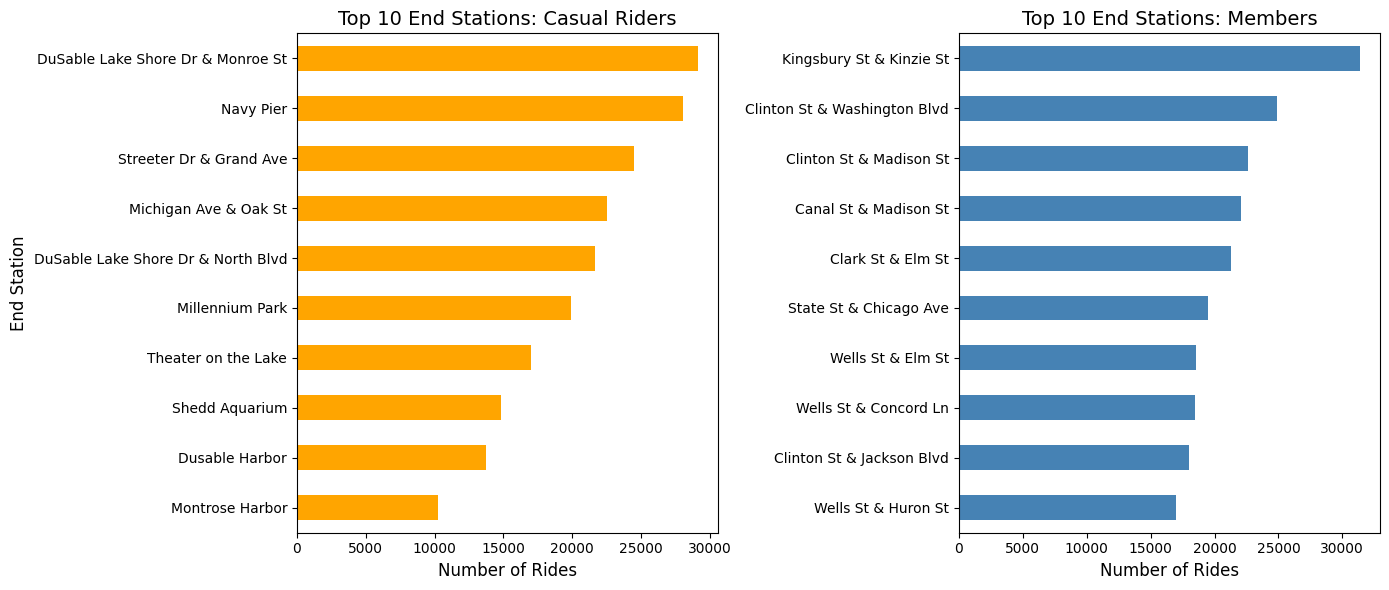

Casual top 10 (end stations):
                      end_station_name  count  proportion_of_casual_total
0   DuSable Lake Shore Dr & Monroe St  29128                        0.01
1                           Navy Pier  28025                        0.01
2             Streeter Dr & Grand Ave  24518                        0.01
3               Michigan Ave & Oak St  22500                        0.01
4  DuSable Lake Shore Dr & North Blvd  21647                        0.01
5                     Millennium Park  19898                        0.01
6                 Theater on the Lake  16999                        0.01
7                      Shedd Aquarium  14836                        0.01
8                      Dusable Harbor  13744                        0.01
9                     Montrose Harbor  10279                        0.01

Member top 10 (end stations):
                end_station_name  count  proportion_of_member_total
0      Kingsbury St & Kinzie St  31381                        0.01


In [31]:
# Top 10 end stations, computed independently within each rider type
casual_top_10_end = df1[df1['member_casual'] == 'casual']['end_station_name'].value_counts().iloc[:10]
member_top_10_end = df1[df1['member_casual'] == 'member']['end_station_name'].value_counts().iloc[:10]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

casual_top_10_end.sort_values().plot(kind='barh', color='orange', ax=axes[0])
axes[0].set_title('Top 10 End Stations: Casual Riders', fontsize=14)
axes[0].set_xlabel('Number of Rides', fontsize=12)
axes[0].set_ylabel('End Station', fontsize=12)

member_top_10_end.sort_values().plot(kind='barh', color='steelblue', ax=axes[1])
axes[1].set_title('Top 10 End Stations: Members', fontsize=14)
axes[1].set_xlabel('Number of Rides', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Exact figures
casual_top_10_end_table = casual_top_10_end.reset_index()
casual_top_10_end_table.columns = ['end_station_name', 'count']
casual_top_10_end_table['proportion_of_casual_total'] = casual_top_10_end_table['count'] / (df1['member_casual'] == 'casual').sum()

member_top_10_end_table = member_top_10_end.reset_index()
member_top_10_end_table.columns = ['end_station_name', 'count']
member_top_10_end_table['proportion_of_member_total'] = member_top_10_end_table['count'] / (df1['member_casual'] == 'member').sum()

print("Casual top 10 (end stations):\n", casual_top_10_end_table.round(3))
print("\nMember top 10 (end stations):\n", member_top_10_end_table.round(3))

**Key Findings — Top 10 End Stations by Rider Type:**

**Casual riders** show the same touristic/lakefront preference as their start stations:
- Most-used station: DuSable Lake Shore Dr & Monroe St (29,128 rides, ~1% of all casual rides)
- Followed by Navy Pier (28,025 rides) and Streeter Dr & Grand Ave (24,518 rides)
- Montrose Harbor newly appears in the end-station top 10 (10,279 rides), replacing Michigan Ave & 8th St from the start-station list — otherwise the same set of lakefront/tourist landmarks recurs

**Members** show the same business-district preference as their start stations:
- Most-used station: Kingsbury St & Kinzie St (31,381 rides)
- Followed by Clinton St & Washington Blvd (24,870 rides) and Clinton St & Madison St (22,658 rides)
- All 10 stations are identical to the start-station top 10 list, just in a slightly different order

**Key insight:** the near-total overlap between each group's top 10 start and end stations — same stations, similar rankings — suggests these are largely **round-trip or short-loop rides** rather than one-way point-to-point commuting between two distinct locations. This is especially notable for members: if their trips were purely linear commutes (e.g., home → office), we might expect start and end stations to differ more (e.g., a residential station leading, a business-district station trailing). Instead, the same business-district cluster dominates both ends, suggesting many member trips may be short work-day errands or loop-based commutes within the same district rather than fixed A-to-B commuting. This is a hypothesis worth mentioning for further investigation (e.g., analyzing individual ride-level start/end pairs) but out of scope of this analysis.

In [32]:
# Sample the data if it's large, to keep the map responsive (folium struggles with millions of points)
# Adjust sample size as needed - 50k-100k points is usually plenty to show density patterns
sample_df = df1.sample(n=100000, random_state=42) if len(df1) > 100000 else df1

# Folium needs a list of [lat, lng] pairs
heat_data = sample_df[['start_lat', 'start_lng']].dropna().values.tolist()

# Center the map on Chicago (or use the mean of your coordinates)
chicago_center = [df1['start_lat'].mean(), df1['start_lng'].mean()]

m = folium.Map(location=chicago_center, zoom_start=12, tiles='CartoDB positron')
HeatMap(heat_data, radius=8, blur=6, max_zoom=13).add_to(m)

m

**Key Findings — Folium Heatmap of Ride Start Locations:**

**Ride density is heavily concentrated along two corridors**:
  - The Lake Michigan shoreline shows a near-continuous band of high-density ride starts, stretching from the northern lakefront trail down through Navy Pier and into the South Loop
  - The downtown Loop/West Loop business district shows a second, equally dense concentration slightly inland from the lakefront
  - Density drops off sharply moving away from these two corridors, with only scattered pockets of moderate activity elsewhere in the city

**Key insight:** the heatmap provides strong visual confirmation of the station-level findings from the bar charts — ride activity is not evenly distributed across Chicago, but instead concentrated in exactly the two zones already identified as casual-heavy (lakefront) and member-heavy (downtown business district). This spatial concentration, visible independent of any station name or ranking, reinforces that the leisure-vs-commuter divide is not just a pattern in aggregated counts, but a real geographic phenomenon.

In [33]:
# Get average coordinates for each top 10 start station (member + casual combined)
top_stations_combined = list(set(casual_top_10.index) | set(member_top_10.index))

# Pull average lat/lng per station name (stations can have slight coordinate variation across rides)
station_coords = df1[df1['start_station_name'].isin(top_stations_combined)].groupby('start_station_name').agg(
    lat=('start_lat', 'mean'),
    lng=('start_lng', 'mean')
).reset_index()

# Merge with member/casual counts to determine dominant rider type per station
station_summary = df1[df1['start_station_name'].isin(top_stations_combined)].groupby(
    ['start_station_name', 'member_casual'], observed=True
).size().reset_index(name='count')

station_pivot = station_summary.pivot(index='start_station_name', columns='member_casual', values='count').fillna(0)
station_pivot['total'] = station_pivot['member'] + station_pivot['casual']
station_pivot['dominant_type'] = station_pivot.apply(
    lambda row: 'member' if row['member'] > row['casual'] else 'casual', axis=1
)
station_pivot = station_pivot.reset_index().merge(station_coords, on='start_station_name')

# Build the map
m = folium.Map(location=[df1['start_lat'].mean(), df1['start_lng'].mean()], zoom_start=12, tiles='CartoDB positron')

for _, row in station_pivot.iterrows():
    color = 'steelblue' if row['dominant_type'] == 'member' else 'orange'
    popup_text = (
        f"<b>{row['start_station_name']}</b><br>"
        f"Total rides: {int(row['total']):,}<br>"
        f"Member: {int(row['member']):,} | Casual: {int(row['casual']):,}<br>"
        f"Dominant: {row['dominant_type']}"
    )
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=10,
        popup=folium.Popup(popup_text, max_width=250),
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8
    ).add_to(m)

m

**Key Findings — Folium Map of Top Stations:**

**Geographic separation between rider types is visually stark**:
- Casual-dominant stations (orange) form a near-continuous line along the Lake Michigan shoreline, from Theater on the Lake in the north down through Navy Pier and Streeter Dr & Grand Ave
- Member-dominant stations (blue) cluster inland, concentrated around the Loop and West Loop business district

**No overlap or blending between the two clusters** — there is a clear geographic boundary between the lakefront corridor and the inland business core, with no member-dominant stations appearing directly on the shoreline and no casual-dominant stations appearing deep in the business district

**Key insight:** this map provides the clearest visual confirmation yet of the leisure-vs-commuter divide established throughout this analysis. The lakefront/inland split isn't just a statistical pattern in a bar chart — it is a literal, walkable geographic boundary in Chicago. This has direct implications for recommendation strategies: physical marketing (e.g., on-dock signage, station-based promotions) aimed at converting casual riders to members could be precisely targeted at these lakefront stations, where casual riders — the target group — are physically concentrated.

### 4.7 Summary of EDA Findings

**Overall Rider Composition:**
- Members account for 64% of all rides (3,552,530), while casual riders account for 36% (1,994,691) — members are the larger segment, but casual riders still represent a substantial share of overall volume

**Ride Duration:**
- Casual riders ride notably longer on average (19.10 minutes) than members (11.95 minutes) — roughly 7 minutes longer per trip
- Casual riders also show a wider spread of ride durations (IQR: 6.30–21.05 minutes, IQR width 14.75) compared to members (IQR: 5.03–14.50 minutes, IQR width 9.47), indicating more variable, less routine trip lengths

**Bike Type Preference:**
- Both groups strongly favor electric bikes over classic bikes, with casual riders showing a marginally higher preference (67% vs. 64% for members)

**Hourly Pattern:**
- Members show a **clear bimodal pattern** consistent with commuting: a first peak at 8:00 (approx. 255,000 rides) and a second, higher peak at 17:00 (approx. 380,000 rides)
- Casual riders show a **unimodal pattern** consistent with leisure: a single peak at 17:00 (~190,000 rides)
- By broader time-of-day grouping, members' Morning + Afternoon periods together account for ~61% of all member rides, while casual riders' Morning + Afternoon periods account for ~57% of all casual rides — both groups concentrate in daytime hours, but members show the sharper, dual-peaked commute signature

**Weekday vs. Weekend:**
- Members show significantly higher weekday ridership: weekday rides (~2,720,000) represent 77% of all member rides
- Casual riders show a more balanced pattern: weekday rides (~1,251,000) represent 63% of all casual rides — still weekday-leaning, but far less concentrated than members
- This confirms members show a strong weekday, work-related usage pattern, while casual riders show a more balanced, less commute-driven pattern
- Faceting the hourly pattern by day (R/ggplot2) reveals that members' bimodal, commute-driven shape on weekdays shifts to a unimodal, leisure-driven shape on weekends — converging with casual riders' pattern. This is the clearest evidence that members use Cyclistic for two distinct purposes depending on the day: commuting on weekdays, leisure on weekends

**Seasonal Patterns:**
- Members show consistently high ridership across all warmer seasons: lowest in Winter (approx. 350,000 rides, still far above casual's winter floor), rising through Spring (approx. 795,000) to a Summer peak (approx. 1,270,000, 36% of all member rides), and remaining elevated in Fall (approx. 1,130,000, 32% of all member rides) — only a modest drop from Summer
- Casual riders show a much steeper seasonal concentration: minimal in Winter (approx. 75,000 rides), rising through Spring (approx. 375,000) to a Summer peak (approx. 950,000, nearly half of all casual rides at 48%), then dropping sharply in Fall (approx. 585,000, 29% of all casual rides) — a much steeper decline than members
- Average ride duration follows the same seasonal shape for both groups but at very different scales: casual riders' average duration ranges from ~10-12 minutes (Dec-Feb) to ~21-22 minutes (Jun-Jul) — roughly double their winter baseline — while members range only from ~10-11 minutes to ~13 minutes over the same period

**Station & Geospatial Patterns:**
- Casual riders show a clear preference for touristic and lakefront locations: their most-used station is DuSable Lake Shore Dr & Monroe St (31,236 rides, ~1.57% of all casual rides), followed by Navy Pier and Streeter Dr & Grand Ave
- Members show a clear preference for central business-district stations: their most-used station is Kingsbury St & Kinzie St (31,202 rides), followed by Clinton St & Washington Blvd and Clinton St & Madison St
- The Folium heatmap of start locations and the Folium map of top stations both support this pattern: ride density is highest along the lakefront and downtown corridor, with casual-dominant stations clustered at or near Lake Michigan and member-dominant stations clustered centrally in the business district
- *Note: "touristic" and "business-district" labels are qualitative interpretations based on station names and Chicago geography, not a field in the data — see the caveat in Section 4.6 for details*

**Overall Key Insight:** every dimension examined — time of day, day of week, season, ride duration, and station location — points to the same underlying divide: **members use Cyclistic primarily for commuting**, riding on a consistent weekday, bimodal schedule from business-district stations, while **casual riders use Cyclistic primarily for leisure**, riding longer trips concentrated on weekends and in summer, from lakefront and tourist-adjacent stations. This consistent pattern across every independent analysis — not just one chart — is the strongest basis for the recommendations that follow.

## 5. Top Three Recommendations

**1. Electric Bike-Focused Membership Incentives**

Both rider groups show a strong shared preference for electric bikes (67% of casual rides, 64% of member rides), making this a low-risk, high-relevance lever for conversion — it appeals to casual riders' existing behavior rather than asking them to change it.

- Offer discounted electric bike rental rates or reduced unlock fees exclusively for members
- Partner with electric bike manufacturers (e.g., Trek, Specialized) for early access to new models and improved customer service/charging-station support for members
- Promote via content and affiliate marketing (manufacturer co-branded posts, comparison videos) highlighting member-exclusive e-bike perks

**Key insight:** since electric bike preference is nearly identical across both groups, this incentive requires no behavioral shift from casual riders — it simply rewards a preference they already have, making it a low-friction entry point into membership consideration.

**2. Seasonal & Shoulder-Month Conversion Campaigns**

Casual ridership is heavily concentrated in summer (48% of all casual rides occur in Jun-Aug), and the casual-to-member ratio peaks even earlier — in June (75.3%) — before absolute volumes do. This points to a narrow but high-value window where casual riders are highly active but haven't yet settled into a summer-only usage pattern.

- Launch targeted membership promotions in the shoulder months (May-June, September), before/after the peak summer surge, when casual riders are already riding frequently but conversion intent may be highest
- Offer time-limited "rides-for-free" or discounted-week promotions timed to this window, rather than spreading incentives evenly across the year
- Deliver via social media content and email marketing campaigns scheduled specifically around these shoulder-month windows, rather than a generic year-round campaign

**Key insight:** targeting the ratio peak (not just the volume peak) means reaching casual riders at the moment they're most representative of "regular" usage relative to members — a more efficient use of marketing spend than targeting the absolute summer peak, when casual riders may simply be one-time tourists less likely to convert.

**3. Landmark & Attraction-Based Membership Benefits**

Casual riders' top stations are consistently clustered around lakefront tourist attractions — DuSable Lake Shore Dr & Monroe St, Navy Pier, Streeter Dr & Grand Ave, Millennium Park, Shedd Aquarium — a pattern confirmed both in the station bar charts and the Folium geospatial maps.

- Partner with Navy Pier, Millennium Park, and Shedd Aquarium to offer discounted or bundled attraction access for Cyclistic members
- Offer reduced prices on lakefront/river sightseeing cruises as a member-exclusive perk
- Promote via geo-targeted social media ads and station-based QR codes specifically at these lakefront stations, reaching casual riders at the exact locations where they already ride most

**Key insight:** this recommendation directly leverages the strongest, most consistent geographic finding in the analysis — casual riders are not just leisure riders in the abstract, they are concentrated at specific, identifiable, partnership-ready locations, making this the most precisely targetable of the three recommendations.

## 6. Conclusion


### 6.1 Key Findings

- **Overall Rider Composition:** Members are the largest rider type, accounting for 64% of all rides (3,552,530), while casual riders form a substantial minority at 36% (1,994,691).

- **Ride Duration:** Casual riders ride approximately 7 minutes longer on average (19.10 minutes) than members (11.95 minutes), and show a wider spread of ride durations (IQR: 6.30–21.05 minutes) compared to members (IQR: 5.03–14.50 minutes).

- **Bike Type Preference:** Both groups prefer electric bikes over classic bikes, with casual riders showing a marginally higher preference (67% vs. 64% for members).

- **Hourly Pattern:** Members show a clear bimodal pattern — a first peak at 8:00 (approx. 255,000 rides) and a second, higher peak at 17:00 (approx. 380,000 rides) — while casual riders show a unimodal pattern with a single peak at 17:00 (approx. 190,000 rides). This confirms members' commuter behavior versus casual riders' leisure-oriented usage.

- **Weekday vs. Weekend:** Members ride significantly more on weekdays (approx. 2,720,000 rides, 77% of all member rides); casual riders also lean weekday (approx. 1,251,000 rides, 63% of all casual rides), but far less concentrated. Faceting the hourly pattern by day (R/ggplot2) revealed that members' bimodal, commute-driven pattern on weekdays shifts to a unimodal, leisure-driven pattern on weekends — converging with casual riders' pattern, and confirming members use Cyclistic for two distinct purposes depending on the day.

- **Seasonal Patterns:** Members show high ridership across all warmer seasons (Summer peak ~1,270,000 rides, 36% of all member rides; Fall ~1,130,000, 32%), while casual riders show a steeper seasonal concentration (Summer peak ~950,000 rides, 48% of all casual rides; Fall drop to ~585,000, 29%). Average ride duration follows the same seasonal shape for both groups but at very different scales — casual riders' duration ranges from ~10-12 minutes (Dec-Feb) to ~21-22 minutes (Jun-Jul), while members range only from ~10-11 to ~13 minutes over the same period.

- **Station & Geospatial Patterns:** Casual riders prefer touristic and lakefront locations — most-used station DuSable Lake Shore Dr & Monroe St (31,236 rides, ~1.57% of all casual rides), followed by Navy Pier and Streeter Dr & Grand Ave. Members favor central business-district stations — most-used station Kingsbury St & Kinzie St (31,202 rides), followed by Clinton St & Washington Blvd and Clinton St & Madison St. These findings are supported by the Folium heatmap of start locations and the Folium map of top stations.
*Note: "touristic" and "business-district" labels are qualitative interpretations based on station names and Chicago geography, not a field in the data — see the caveat in Section 4.6 for details.*

- **Overall Key Insight:** Across every dimension examined, one consistent divide emerged — members mainly ride for commuting, casual riders mostly use Cyclistic for leisure. This divide, established throughout Section 4, directly shapes the recommendations below.

### 6.2 Business Recommendations

Based on the key findings above, and with regard to questions 2 (*Why would casual riders buy Cyclistic annual memberships?*) and 3 (*How can Cyclistic use digital media to influence casual riders to become members?*), the top three recommendations are:

- **Electric Bike-Focused Membership Incentives** — Offer members-only discounts on e-bike rentals, partner with manufacturers (e.g., Trek, Specialized) for early access and better support, and promote through co-branded content and affiliate marketing.
- **Seasonal & Shoulder-Month Conversion Campaigns** — Launch targeted membership promotions in the shoulder months (May-June, September), when casual riders are active but not yet locked into summer-only habits, delivered via timed social media and email campaigns.
- **Landmark & Attraction-Based Membership Benefits** — Partner with lakefront attractions (Navy Pier, Millennium Park, Shedd Aquarium) and sightseeing cruises for member-exclusive discounts, promoted via geo-targeted ads and station-based QR codes at casual riders' top stations.


### 6.3 Limitations & Further Research

This analysis has the following limitations, which also point toward directions for further research:

- **No demographic data** (age, gender) is available — segmentation is only possible by member/casual status, however, rider demographics could offer further insights.
- **"Touristic" vs. "business-district" station classifications** are qualitative and name-based, not derived from an actual land-use dataset (see Section 4.6); joining station coordinates against an external POI/land-use dataset (e.g., OpenStreetMap) could programmatically validate this classification.
- **Start/end station overlap** suggests possible round-trip behavior, but this was not directly tested; a per-ride start→end station pair analysis (e.g., a Sankey flow diagram) could properly test this hypothesis.
- **Single calendar year (2025)** — a multi-year time series analysis was out of scope, limiting the ability to distinguish genuine seasonal trends from one-year anomalies (e.g., unusual weather, one-off events).
- **2025 station network expansion** (140+ new/upgraded stations) means station-level comparisons with other Cyclistic analyses using different years should account for this change.
- **A/B testing or a pilot rollout** of the Section 5 recommendations (e.g., a limited shoulder-month promotion) would help validate actual conversion impact before a full-scale campaign.

In [34]:
# Confirm successful end-to-end run and timestamp it
from datetime import datetime
import pytz

chicago_tz = pytz.timezone('America/Chicago')
berlin_tz = pytz.timezone('Europe/Berlin')

run_time_chicago = datetime.now(chicago_tz)
run_time_berlin = datetime.now(berlin_tz)

print("✅ Notebook executed successfully end-to-end (Runtime → Restart and run all).")
print(f"Last successful run (Chicago): {run_time_chicago.strftime('%Y-%m-%d %H:%M:%S %Z%z')}")
print(f"Last successful run (Germany): {run_time_berlin.strftime('%Y-%m-%d %H:%M:%S %Z%z')}")
print(f"Total rows analyzed: {len(df1):,}")

✅ Notebook executed successfully end-to-end (Runtime → Restart and run all).
Last successful run (Chicago): 2026-07-28 15:30:18 CDT-0500
Last successful run (Germany): 2026-07-28 22:30:18 CEST+0200
Total rows analyzed: 5,547,221
